### Import

In [1]:
import os
import gc
import time
import pickle 
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm
import matplotlib.ticker as ticker
from matplotlib import pyplot as plt
from plot_metric.functions import BinaryClassification

from sklearn.metrics import auc
from sklearn.metrics import f1_score 
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.isotonic import IsotonicRegression

from aequitas.bias import Bias
from aequitas.group import Group
from aequitas.plotting import Plot
from aequitas.fairness import Fairness

from pynvml import *
import GPUtil
from threading import Thread

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader
from torch.utils.data import Dataset as t_Dataset
from torch.utils.data.sampler import WeightedRandomSampler

from torch.nn.utils.rnn import pad_packed_sequence
from torch.nn.utils.rnn import pack_padded_sequence

import evaluate
import datasets

from datasets import DatasetDict
from datasets import load_dataset
from datasets import list_metrics
from datasets import load_from_disk
from datasets import Dataset as d_Dataset

from transformers import get_scheduler
from transformers import get_linear_schedule_with_warmup

from transformers import BertModel
from transformers import AutoModel
from transformers import AutoTokenizer
from transformers import DataCollatorWithPadding
from transformers import AutoModelForSequenceClassification

from captum.attr import visualization as viz
from captum.attr import LayerConductance
from captum.attr import LayerIntegratedGradients

from bertviz import head_view
from bertviz import model_view

from transformers import utils
utils.logging.set_verbosity_error() 

### General parameters

In [2]:
race_path = "Extraction/MIMICIII/Data/csvExtract/"
path_ehr_data = "../Data/EHR/"
path_txt_data = "../Data/TEXT/"
path_cohort   = "../Data/Cohorts/"
result_path   = '../Results/'
best_model    = "../checkpoints/"

### Read Cohorts Splits

In [3]:
with open(path_cohort + "short_icustays", "rb") as fp:   
    short_icustays = pickle.load(fp)
    
with open(path_cohort + "train_icustays", "rb") as fp:   
    train_icustays = pickle.load(fp)
    
with open(path_cohort + "valid_icustays", "rb") as fp:   
    valid_icustays = pickle.load(fp)
    
with open(path_cohort + "test_icustays", "rb") as fp:   
    test_icustays = pickle.load(fp)
    
with open(path_cohort + "icustays_ehr_text", "rb") as fp:   
    icustays_ehr_text = pickle.load(fp)
    
with open(path_cohort + "icustays_ehr_only", "rb") as fp:   
    icustays_ehr_only = pickle.load(fp)
    
with open(path_cohort + "note_ids_24h", "rb") as fp:   
    note_ids_24h = pickle.load(fp)

### Notes

In [7]:
df_notes = load_from_disk(path_txt_data + "MIMICIII_CLEAN_NOTES")
df_temp = df_notes.to_pandas()
df_temp['ICU_EXPIRE_FLAG'] = df_temp['ICU_EXPIRE_FLAG'].astype(int)
df_temp['HOSPITAL_EXPIRE_FLAG'] = df_temp['HOSPITAL_EXPIRE_FLAG'].astype(int)
df_notes = d_Dataset.from_pandas(df_temp)
df_notes

Dataset({
    features: ['ICUSTAY_ID', 'ICU_EXPIRE_FLAG', 'HOSPITAL_EXPIRE_FLAG', 'CATEGORY', 'ROW_ID', 'TEXT'],
    num_rows: 1133816
})

### Notes in First 24 Hours

In [8]:
df_notes = df_notes.filter(lambda example: example['ROW_ID'] in note_ids_24h)

Filter:   0%|          | 0/1133816 [00:00<?, ? examples/s]

### EHR

In [9]:
df_ehr = pd.read_csv(path_ehr_data + '0h_to_24h_data.csv', low_memory=False, index_col=False)
df_ehr.head(2)

In [10]:
print(df_ehr.ICUSTAY_ID.nunique())
print(df_ehr.shape)

59653
(1364554, 543)


### Drop Repeated Rows

In [14]:
all_columns = list(df_ehr.columns)
remove_columns = [col for col in all_columns if ('_tslm' in col) or ('_diff' in col)]

text_columns = ['Note', 'Discharge_Note', 'Heart Rhythm', 'Ventilator Mode', 'Ventilator Type', 'Ventilator']

remove_columns.extend(text_columns)
df_ehr.drop(remove_columns, axis=1, inplace=True)
df_ehr = df_ehr.drop_duplicates()

print(df_ehr.ICUSTAY_ID.nunique())
print(df_ehr.shape)

### Read Comorbidities

In [20]:
all_comorbidity = pd.read_csv(path_ehr_data + 'comorbidity_all.csv', index_col=False)
all_comorbidity.drop(columns=['SUBJECT_ID', 'HADM_ID'], inplace=True)
all_comorbidity.head(3)

In [21]:
print(all_comorbidity.ICUSTAY_ID.nunique())
print(all_comorbidity.shape)

59801
(59801, 31)


### Take first hours of ICU of patients with more than 24 hour LoS

In [22]:
max_rows = df_ehr.groupby('ICUSTAY_ID').count()
observation_window = max_rows.Bins.max()
print(observation_window)

24


In [23]:
def take_observation_window(df, observation_window):
    df = df.groupby('ICUSTAY_ID').head(observation_window).reset_index(drop=True)
    return df

df_ehr = take_observation_window(df_ehr, observation_window)

### Spliting Train - Validation - Test

In [25]:
split_label = 'HOSPITAL_EXPIRE_FLAG'
label = 'ICU_EXPIRE_FLAG'

In [26]:
train_df = df_ehr[df_ehr.ICUSTAY_ID.isin(train_icustays)]
valid_df = df_ehr[df_ehr.ICUSTAY_ID.isin(valid_icustays)]
test_df  = df_ehr[df_ehr.ICUSTAY_ID.isin(test_icustays)]

train_df.sort_values(by=['ICUSTAY_ID', 'Bins'], inplace=True)
valid_df.sort_values(by=['ICUSTAY_ID', 'Bins'], inplace=True)
test_df.sort_values( by=['ICUSTAY_ID', 'Bins'], inplace=True)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

In [28]:
train_comor = all_comorbidity[all_comorbidity.ICUSTAY_ID.isin(train_icustays)]
valid_comor = all_comorbidity[all_comorbidity.ICUSTAY_ID.isin(valid_icustays)]
test_comor  = all_comorbidity[all_comorbidity.ICUSTAY_ID.isin(test_icustays)]

train_comor = train_comor.reset_index(drop=True)
valid_comor = valid_comor.reset_index(drop=True)
test_comor  = test_comor.reset_index(drop=True)

In [29]:
del df_ehr
del all_comorbidity
gc.collect()

80

### Note Split

In [30]:
index_train = train_df.ICUSTAY_ID.unique()
index_valid = valid_df.ICUSTAY_ID.unique()
index_test  = test_df.ICUSTAY_ID.unique()

df_train_dataset = df_notes.filter(lambda example: example['ICUSTAY_ID'] in index_train)
df_valid_dataset = df_notes.filter(lambda example: example['ICUSTAY_ID'] in index_valid)
df_test_dataset  = df_notes.filter(lambda example: example['ICUSTAY_ID'] in index_test)

Filter:   0%|          | 0/248957 [00:00<?, ? examples/s]

Filter:   0%|          | 0/248957 [00:00<?, ? examples/s]

Filter:   0%|          | 0/248957 [00:00<?, ? examples/s]

### Checkpoint

In [31]:
# ORIGINAL TEXT
checkpoint = "bert-base-cased"
# checkpoint = "bert-large-cased"

### Tokenizer

In [32]:
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

In [33]:
def tokenize_split_filtered(examples):
    
    min_token_len = 75

    result = tokenizer(examples["TEXT"], truncation=True, max_length=tokenizer.model_max_length, return_overflowing_tokens=True)
    sample_map = result.pop("overflow_to_sample_mapping")
    
    filtered_result = {key: [] for key in result}
    filtered_result["overflow_to_sample_mapping"] = [] 
    
    original_lengths = [len(tokenizer.encode(text, add_special_tokens=False)) for text in examples["TEXT"]]
    
    for idx, mapping_index in enumerate(sample_map):
        if original_lengths[mapping_index] < tokenizer.model_max_length and len(result['input_ids'][idx]) < min_token_len:
            for key in filtered_result:
                if key != "overflow_to_sample_mapping":  
                    filtered_result[key].append(result[key][idx])
            filtered_result["overflow_to_sample_mapping"].append(mapping_index)
        elif len(result['input_ids'][idx]) >= min_token_len:
            for key in filtered_result:
                if key != "overflow_to_sample_mapping":  
                    filtered_result[key].append(result[key][idx])
            filtered_result["overflow_to_sample_mapping"].append(mapping_index)
    
    for key, values in examples.items():
        filtered_result[key] = [values[i] for i in filtered_result["overflow_to_sample_mapping"]]
    
    return filtered_result

In [34]:
def tokenize_split_overflow(examples):
    
    result = tokenizer(examples["TEXT"], truncation=True, max_length=512, return_overflowing_tokens=True)
    sample_map = result.pop("overflow_to_sample_mapping")
    
    for key, values in examples.items():
        result[key] = [values[i] for i in sample_map]
        
    return result

In [35]:
train_tokenized = df_train_dataset.map(tokenize_split_filtered, batched=True)
valid_tokenized = df_valid_dataset.map(tokenize_split_overflow, batched=True)
test_tokenized  = df_test_dataset.map( tokenize_split_overflow, batched=True)

train_tokenized = train_tokenized.remove_columns(['overflow_to_sample_mapping'])

Map:   0%|          | 0/156640 [00:00<?, ? examples/s]

Map:   0%|          | 0/15599 [00:00<?, ? examples/s]

Map:   0%|          | 0/39229 [00:00<?, ? examples/s]

### Final Dataset

In [36]:
df_overflow_tokenized = DatasetDict(train= train_tokenized, valid= valid_tokenized, test= test_tokenized)
df_overflow_tokenized

DatasetDict({
    train: Dataset({
        features: ['ICUSTAY_ID', 'ICU_EXPIRE_FLAG', 'HOSPITAL_EXPIRE_FLAG', 'CATEGORY', 'ROW_ID', 'TEXT', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 178336
    })
    valid: Dataset({
        features: ['ICUSTAY_ID', 'ICU_EXPIRE_FLAG', 'HOSPITAL_EXPIRE_FLAG', 'CATEGORY', 'ROW_ID', 'TEXT', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 18372
    })
    test: Dataset({
        features: ['ICUSTAY_ID', 'ICU_EXPIRE_FLAG', 'HOSPITAL_EXPIRE_FLAG', 'CATEGORY', 'ROW_ID', 'TEXT', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 46049
    })
})

### Keep Original Test Data

In [37]:
original_test_dataset = df_overflow_tokenized["test"]

### Select Column in Text Data

In [38]:
df_overflow_tokenized = df_overflow_tokenized.remove_columns(['HOSPITAL_EXPIRE_FLAG', 'CATEGORY', 'ROW_ID', 'TEXT'])
df_overflow_tokenized = df_overflow_tokenized.rename_column("ICU_EXPIRE_FLAG", "labels")
df_overflow_tokenized

DatasetDict({
    train: Dataset({
        features: ['ICUSTAY_ID', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 178336
    })
    valid: Dataset({
        features: ['ICUSTAY_ID', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 18372
    })
    test: Dataset({
        features: ['ICUSTAY_ID', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 46049
    })
})

### Select Relevant Columns in EHR

In [39]:
continuse_col = ['Heart Rate', 'SpO2', 'SvO2', 'Oxygen Saturation', 'Respiratory Rate', 'Respiratory Rate (Total)',
                 'Respiratory Rate (Set)', 'Temperature', 'Non Invasive Blood Pressure mean',
                 'Non Invasive Blood Pressure systolic', 'Non Invasive Blood Pressure diastolic',
                 'Arterial Blood Pressure mean', 'Arterial Blood Pressure systolic', 
                 'Arterial Blood Pressure diastolic', 'Glucose', 'Creatinine', 'Base Excess', 'BUN', 'Anion Gap',
                 'Bicarbonate', 'Lactate', 'Lactate Dehydrogenase (LD)', 'Hemoglobin', 'Hematocrit', 'pH', 
                 'Bilirubin, Direct', 'Bilirubin, Indirect', 'Bilirubin, Total', 'pO2', 'pCO2', 'PT', 'PTT', 
                 'INR(PT)', 'AST', 'ALT', 'WBC', 'RBC', 'RDW', 'White Blood Cells', 'Red Blood Cells',
                 'Platelet Count', 'MCV', 'MCH', 'MCHC', 'Potassium', 'Sodium', 'Chloride', 'Magnesium',
                 'Phosphate', 'Alkaline Phosphatase', 'Ionized Calcium', 'Calcium non-ionized', 'Calcium, Total',
                 'Protein', 'Total Protein', 'Cholesterol, Total', 'Differential-Bands', 'Differential-Monos', 
                 'Differential-Lymphs', 'Differential-Eos', 'Differential-Basos', 'Differential-Neuts', 'Oxygen',
                 'O2 Flow', 'Total CO2', 'Flow Rate (L/min)', 'Mean Airway Pressure',
                 'Plateau Pressure', 'CVP', 'Amylase', 'Albumin', 'Fibrinogen', 'Triglycerides',
                 'Transferrin', 'Ferritin', 'Troponin T', 'Vancomycin (Trough)', 'Vancomycin (Random)',
                 'C-Reactive Protein (CRP)', 'FiO2', 'PEEP', 'PEEP (Set)', 'Tidal Volume',
                 'Tidal Volume (Set)', 'Ventilation Rate', 'UrineOutput_IO', 'Mg-nonIV_IO', 'Insulin_IO',
                 'K-IV_IO', 'Propofol_IO', 'Heparin_IO', 'Vasopressors_IO', 'Fentanyl_IO', 'Crystalloids_IO',
                 'Vancomycin_IO','P.O._IO', 'Dextrose_IO']

categorical_col = ['Skin Temperature', 'GCS Total', 'GCS - Eye Opening',  'GCS - Verbal Response',  
                   'GCS - Motor Response' , 'Richmond-RAS Scale', 'Goal Richmond-RAS Scale', 'Pain Level', 
                   'Microbio Test',]

binary_col = ['Pain Present', 'Mental status', 'Risk for Falls', 'Delirium assessment', 'CAM-ICU MS Change',
              'CAM-ICU Inattention', 'CAM-ICU Disorganized thinking', 'CAM-ICU RASS LOC',  'CAM-ICU Altered LOC',
              'Intubated', 'Norepinephrine_PRC', 'Fentanyl_PRC', 'Antibiotic_PRC', 'Heparin_PRC', 'Insulin_PRC', 
              'Propofol_PRC', 'Phenylephrine_PRC', 'Vasopressin_PRC', 'Epinephrine_PRC', 'Pantoprazole_PRC',
              'Blood Culture']

risk_scores = ['PaO2/FiO2', 'SIRS', 'Shock_Index', 'SOFA', 'SAPSII', 'OASIS']

static_col = ['AGE', 'GENDER', 'ETHNICITY', 'Weight', 'Height']

textual_col = ['Heart Rhythm', 'Ventilator Mode', 'Ventilator Type', 'Ventilator',
               'Sedation Score', 'Sedation Scale', 'EtCO2 Clinical indication']

comorbidity = ['congestive_heart_failure', 'cardiac_arrhythmias', 'valvular_disease', 'pulmonary_circulation', 
               'peripheral_vascular', 'hypertension', 'paralysis', 'other_neurological', 'chronic_pulmonary',
               'diabetes_uncomplicated', 'diabetes_complicated', 'hypothyroidism', 'renal_failure', 
               'liver_disease', 'peptic_ulcer', 'aids', 'lymphoma', 'metastatic_cancer', 'solid_tumor', 
               'rheumatoid_arthritis', 'coagulopathy', 'obesity', 'weight_loss', 'fluid_electrolyte',
               'blood_loss_anemia', 'deficiency_anemias', 'alcohol_abuse', 'drug_abuse', 'psychoses', 'depression']

### Imputation

In [40]:
def Imputation(train_df, valid_df, test_df, continuse_col, categorical_col, binary_col, risk_scores):
    
    train_df['Weight'] = train_df.groupby(['ICUSTAY_ID'])['Weight'].transform('mean')
    valid_df['Weight'] = valid_df.groupby(['ICUSTAY_ID'])['Weight'].transform('mean') 
    test_df[ 'Weight'] = test_df.groupby( ['ICUSTAY_ID'])['Weight'].transform('mean') 
    train_df['Height'] = train_df.groupby(['ICUSTAY_ID'])['Height'].transform('mean') 
    valid_df['Height'] = valid_df.groupby(['ICUSTAY_ID'])['Height'].transform('mean') 
    test_df[ 'Height'] = test_df.groupby( ['ICUSTAY_ID'])['Height'].transform('mean') 
    valid_df['Weight'].fillna((train_df['Weight'].mean()), inplace=True)
    test_df[ 'Weight'].fillna((train_df['Weight'].mean()), inplace=True)
    train_df['Weight'].fillna((train_df['Weight'].mean()), inplace=True)
    valid_df['Height'].fillna((train_df['Height'].mean()), inplace=True)
    test_df[ 'Height'].fillna((train_df['Height'].mean()), inplace=True)
    train_df['Height'].fillna((train_df['Height'].mean()), inplace=True)
    
    for i in sorted(continuse_col):
        valid_df[i].fillna((train_df[i].mean()), inplace=True)
        test_df[ i].fillna((train_df[i].mean()), inplace=True)
        train_df[i].fillna((train_df[i].mean()), inplace=True)
    
    for i in categorical_col:
        valid_df[i].fillna((train_df[i].mode()[0]), inplace=True)
        test_df[ i].fillna((train_df[i].mode()[0]), inplace=True)
        train_df[i].fillna((train_df[i].mode()[0]), inplace=True)
            
    for i in sorted(binary_col):
        train_df[i].fillna(0, inplace=True)
        valid_df[i].fillna(0, inplace=True)
        test_df[ i].fillna(0, inplace=True)
        
    for i in sorted(risk_scores):
        valid_df[i].fillna((train_df[i].mean()), inplace=True)
        test_df[ i].fillna((train_df[i].mean()), inplace=True)
        train_df[i].fillna((train_df[i].mean()), inplace=True)
        
    train_df = train_df.round(2)
    valid_df = valid_df.round(2)
    test_df  = test_df.round(2)
            
    return train_df, valid_df, test_df

In [41]:
train_df, valid_df, test_df = Imputation(train_df, 
                                         valid_df, 
                                         test_df, 
                                         continuse_col, 
                                         categorical_col, 
                                         binary_col, 
                                         risk_scores)

### Columns Order

In [42]:
def order_columns(train_df, static_col, continuse_col, categorical_col, risk_scores, binary_col, 
                  use_diff=False,use_tslm=False):
    
    columns = []
    
    columns.extend(static_col)
    
    column_order = []
    column_order.extend(continuse_col)
    column_order.extend(categorical_col)

    for i in column_order:

        columns.append(i)

        temp_col = i + '_ind'
        if temp_col in list(train_df.columns):
            columns.append(temp_col)
            
        if use_diff:
            temp_col = i + '_diff'
            if temp_col in list(train_df.columns):
                columns.append(temp_col)
        if use_tslm:    
            temp_col = i + '_tslm'
            if temp_col in list(train_df.columns):
                columns.append(temp_col)

    columns.extend(risk_scores)
    columns.extend(binary_col)
    
    return columns

In [43]:
columns = order_columns(train_df, static_col, continuse_col, categorical_col, risk_scores, binary_col)

### Prepare Test Result Frame

In [44]:
def result_frame(data, label):
        
    data = data.groupby(['ICUSTAY_ID'])[['ICUSTAY_ID', 'GENDER', 'AGE', 'ETHNICITY', label]].head(1).copy()
    
    data['ICU_FLAG'] = np.nan
    data.loc[data['ICU_EXPIRE_FLAG'] == 0, 'ICU_FLAG'] = 'Survived'
    data.loc[data['ICU_EXPIRE_FLAG'] == 1, 'ICU_FLAG'] = 'Dead'
    
    return data

In [45]:
train_result = result_frame(train_df, label)
valid_result = result_frame(valid_df, label)
test_result  = result_frame(test_df , label)

train_result = train_result.reset_index(drop=True)
valid_result = valid_result.reset_index(drop=True)
test_result  = test_result.reset_index(drop=True)

### Normalization

In [46]:
def Normalizing(train_df, valid_df, test_df, continuse_col, categorical_col, risk_scores, static_col):
    
    norm = sorted(continuse_col + categorical_col + risk_scores + static_col)
    
    train_val = train_df[norm]
    valid_val = valid_df[norm]
    test_val  = test_df[norm]

    scaler = MinMaxScaler().fit(train_val.values)

    train_normalized = scaler.transform(train_val.values)
    valid_normalized = scaler.transform(valid_val.values)
    test_normalized  = scaler.transform(test_val.values)

    train_df[norm] = train_normalized
    valid_df[norm] = valid_normalized
    test_df[norm]  = test_normalized

    train_df = train_df.round(2)
    valid_df = valid_df.round(2)
    test_df  = test_df.round(2)
    
    return train_df, valid_df, test_df

In [47]:
train_df, valid_df, test_df = Normalizing(train_df, 
                                          valid_df, 
                                          test_df,  
                                          continuse_col, 
                                          categorical_col, 
                                          risk_scores, 
                                          static_col)

### TSLM Normalization

In [48]:
def TSLM_Normalizing(train_df, valid_df, test_df, observation_window):
    
    norm_tslm = []
    for col in list(train_df.columns):
        if '_tslm' in col:
            norm_tslm.append(col)
    
    train_val = train_df[norm_tslm]
    valid_val = valid_df[norm_tslm]
    test_val  = test_df[norm_tslm]

    scaler = MinMaxScaler(feature_range=(-1, observation_window))

    train_normalized = scaler.fit_transform(train_val.values)
    valid_normalized = scaler.fit_transform(valid_val.values)
    test_normalized  = scaler.fit_transform(test_val.values)

    train_df[norm_tslm] = train_normalized
    valid_df[norm_tslm] = valid_normalized
    test_df[norm_tslm]  = test_normalized

    train_df = train_df.round(2)
    valid_df = valid_df.round(2)
    test_df  = test_df.round(2)
    
    return train_df, valid_df, test_df

In [49]:
# train_df, valid_df, test_df = TSLM_Normalizing(train_df, valid_df, test_df, observation_window)

### Diff Normalization

In [50]:
def Diff_Normalizing(train_df, valid_df, test_df):
    
    norm_diff = []
    for col in list(train_df.columns):
        if '_diff' in col:
            norm_diff.append(col)
    
    train_val = train_df[norm_diff]
    valid_val = valid_df[norm_diff]
    test_val  = test_df[norm_diff]

    scaler = MinMaxScaler().fit(train_val.values)

    train_normalized = scaler.transform(train_val.values)
    valid_normalized = scaler.transform(valid_val.values)
    test_normalized  = scaler.transform(test_val.values)

    train_df[norm_diff] = train_normalized
    valid_df[norm_diff] = valid_normalized
    test_df[norm_diff]  = test_normalized

    train_df = train_df.round(2)
    valid_df = valid_df.round(2)
    test_df  = test_df.round(2)
    
    return train_df, valid_df, test_df

In [51]:
# train_df, valid_df, test_df = Diff_Normalizing(train_df, valid_df, test_df)

### EHR Data Preparation

In [52]:
def data_model_ready(train_df, valid_df, test_df, columns, label):
    
    train_data = train_df.groupby(['ICUSTAY_ID'])
    valid_data = valid_df.groupby(['ICUSTAY_ID'])
    test_data  = test_df.groupby(['ICUSTAY_ID'])
    
    X_train = []
    y_train = []
    id_train = []
    for icu_id, frame in train_data:
        X_train.append(frame[columns].values)
        y_train.append(frame.iloc[0][label])
        id_train.append(icu_id)
                
    X_valid = []
    y_valid = []
    id_valid = []
    for icu_id, frame in valid_data:
        X_valid.append(frame[columns].values)
        y_valid.append(frame.iloc[0][label])
        id_valid.append(icu_id)
        
    X_test = []
    y_test = []
    id_test = []
    for icu_id, frame in test_data:
        X_test.append(frame[columns].values)
        y_test.append(frame.iloc[0][label])
        id_test.append(icu_id)
        
    y_train = np.array(y_train)
    y_valid = np.array(y_valid)
    y_test  = np.array(y_test)
        
    pos_tr = y_train[y_train == 1]
    neg_tr = y_train[y_train == 0]
    print('Train= Positive - Negative: ', len(pos_tr), len(neg_tr))
    
    pos_vl = y_valid[y_valid == 1]
    neg_vl = y_valid[y_valid == 0]
    print('Valid= Positive - Negative: ', len(pos_vl), len(neg_vl))
    
    pos_ts = y_test[y_test == 1]
    neg_ts = y_test[y_test == 0]
    print('Test = Positive - Negative: ', len(pos_ts), len(neg_ts))
    
    return X_train, y_train, id_train, X_valid, y_valid, id_valid, X_test, y_test, id_test

In [53]:
X_train, y_train, id_train, X_valid, y_valid, id_valid, X_test, y_test, id_test = data_model_ready(train_df, 
                                                                                                   valid_df, 
                                                                                                   test_df, 
                                                                                                   columns, 
                                                                                                   label)

<ipython-input>:10: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for icu_id, frame in train_data:
<ipython-input>:18: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for icu_id, frame in valid_data:
<ipython-input>:26: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for icu_id, frame in test_data:


Train= Positive - Negative:  3384 35593
Valid= Positive - Negative:  260 3473
Test = Positive - Negative:  669 8625


In [54]:
def data_model_ready(train_comor_df, valid_comor_df, test_comor_df):
    
    train_comor_data = train_comor_df.groupby(['ICUSTAY_ID'])
    valid_comor_data = valid_comor_df.groupby(['ICUSTAY_ID'])
    test_comor_data  = test_comor_df.groupby(['ICUSTAY_ID'])
    
    X_train_comor  = []
    id_train_comor = []
    for icu_id, frame in train_comor_data:
        X_train_comor.append(frame.drop(columns='ICUSTAY_ID').values)
        id_train_comor.append(icu_id)
        
    X_valid_comor  = []
    id_valid_comor = []
    for icu_id, frame in valid_comor_data:
        X_valid_comor.append(frame.drop(columns='ICUSTAY_ID').values)
        id_valid_comor.append(icu_id)
        
    X_test_comor  = []
    id_test_comor = []
    for icu_id, frame in test_comor_data:
        X_test_comor.append(frame.drop(columns='ICUSTAY_ID').values)
        id_test_comor.append(icu_id)
        
    return X_train_comor, id_train_comor, X_valid_comor, id_valid_comor, X_test_comor, id_test_comor

In [55]:
X_train_com, id_train_com, X_valid_com, id_valid_com, X_test_com, id_test_com = data_model_ready(train_comor, 
                                                                                                 valid_comor, 
                                                                                                 test_comor)

<ipython-input>:9: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for icu_id, frame in train_comor_data:
<ipython-input>:15: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for icu_id, frame in valid_comor_data:
<ipython-input>:21: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for icu_id, frame in test_comor_data:


### Data Padding 

In [56]:
def padd(data, max_len):
    
    padded_data = []
    length = []
    
    for item in data:
        tmp = np.zeros((max_len, item.shape[1]))
        
        if item.shape[0] > max_len :
            tmp[:max_len, :item.shape[1]] = item[(item.shape[0] - max_len):, :item.shape[1]]
            length.append(max_len)
            
        else:
            tmp[:item.shape[0], :item.shape[1]] = item
            length.append(item.shape[0])
        
        padded_data.append(tmp)
        
    padded_data = np.array(padded_data)
    length = np.array(length)
    
    return padded_data, length

In [57]:
X_data_train, X_len_train = padd(X_train, observation_window)
X_data_valid, X_len_valid = padd(X_valid, observation_window)
X_data_test,  X_len_test  = padd(X_test , observation_window)

### Plots

In [58]:
def plot_losses(train_losses, valid_losses):
    
    fig = plt.figure(figsize=(10, 5))

    plt.plot(range(1, len(train_losses) + 1), train_losses, 'b-o', label='Training Loss'  , linewidth=2, markersize=5)
    plt.plot(range(1, len(valid_losses) + 1), valid_losses, 'g-s', label='Validation Loss', linewidth=2, markersize=5)

    minposs = valid_losses.index(min(valid_losses)) + 1 
    plt.axvline(minposs, linestyle='--', color='r', linewidth=2, label='Early Stopping Checkpoint')

    plt.xlabel('Epochs', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.title('Training and Validation Loss by Epoch', fontsize=16)
    plt.ylim(0, 1.5)  
    plt.xlim(0, len(train_losses) + 1)

    plt.grid(True, which='major', linestyle='--', linewidth=0.5, color='gray')
    plt.legend(fontsize=12)
    plt.tight_layout()

    ax = plt.gca() 
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True)) 
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.show()

In [59]:
def ROC_curve(true_label, prediction_prob):
    
    AUC = roc_auc_score(true_label, prediction_prob)
    fpr, tpr, roc_thresholds = roc_curve(true_label, prediction_prob)

    fig, ax = plt.subplots(figsize=(4, 3), dpi=120)
    plt.plot(fpr, tpr, color='darkorange', lw=1.2, label='Model (AUC = {:.2f})'.format(AUC))
    plt.plot([0, 1], [0, 1], color='navy', lw=1.2, linestyle='--', label='Random (AUC = 0.50)')
    plt.xlim([-0.01, 1.00])
    plt.ylim([ 0.00, 1.02])
    plt.xlabel('False Positive Rate', fontsize=8)
    plt.ylabel('True Positive Rate', fontsize=8)
    plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [60]:
def PRC_REC_curve(true_label, prediction_prob):
    
    AP = average_precision_score(true_label, prediction_prob)
    precision, recall, pr_thresholds = precision_recall_curve(true_label, prediction_prob)
    no_skill = len(true_label[true_label == 1]) / len(true_label) 

    fig, ax = plt.subplots(figsize=(4, 3), dpi=120)
    plt.plot(recall, precision, color='darkorange', lw=1.2, label='Model (AP = {:.2f})'.format(AP))
    plt.plot([0, 1], [no_skill, no_skill], color='navy', lw=1.2, linestyle='--', label='No Skill (AP = {:.2f})'.format(no_skill))
    plt.xlim([-0.01, 1.00])
    plt.ylim([ 0.00, 1.02])
    plt.xlabel('Recall', fontsize=8)
    plt.ylabel('Precision', fontsize=8)
    plt.title('Precision-Recall Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [61]:
def Calibration_curve(true_label, prediction_prob):
    
    fig, ax = plt.subplots(figsize=(5, 2.5), dpi=120)
    
    frac_of_pos, mean_pred_value = calibration_curve(true_label, prediction_prob, n_bins=10)

    plt.plot([0, 1], [0, 1], "--", label="Perfectly Calibrated", color='navy', lw=1.3)
    plt.plot(mean_pred_value, frac_of_pos, "*-", label='Model Calibration', lw=1.2, color='darkorange')

    plt.ylabel("Fraction of Positives", fontsize=8)
    plt.xlabel("Mean Predicted Value", fontsize=8)
    plt.ylim([-0.05, 1.05])
    plt.xlim([-0.05, 1.05])
    plt.title('Calibration Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [62]:
def Confusion_Matrix(true_label, predicted_label, classes, cmap=plt.cm.OrRd):
    
    cm = confusion_matrix(true_label, predicted_label, labels=[1, 0])

    plt.figure(figsize = (5, 5))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title('Confusion Matrix', size = 14)
    plt.colorbar(aspect=4)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=40, size = 14)
    plt.yticks(tick_marks, classes, size = 14)

    fmt = 'd'
    thresh = cm.max() / 2.
    
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), fontsize = 14,
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
        
    plt.tight_layout()
    plt.ylabel('True Label', size = 13)
    plt.xlabel('Predicted Label', size = 13)
    plt.show()

### Performance 

In [63]:
def Prediction_Labels_Thresholding(true_label, prediction_prob, decision_recall):
    
    precision, recall, pr_thresholds = precision_recall_curve(true_label, prediction_prob)
    
    index = np.argwhere(recall >= decision_recall)[-1][0]
    decision_threshold = pr_thresholds[index]
    predicted_label = (np.array(prediction_prob) > decision_threshold).astype(int)
    
    print("Decision Threshold is: ", np.round(decision_threshold, 2))
    
    return predicted_label, decision_threshold

In [64]:
def Performance_Metrics(true_label, predicted_label, prediction_prob):
    
    TN, FP, FN, TP = confusion_matrix(true_label, predicted_label).ravel()

    ACC = (TP+TN)/(TP+FP+FN+TN)
    PRC = TP/(TP+FP)
    REC = TP/(TP+FN)
    F1M = (2*PRC*REC)/(PRC+REC)
    PPV = TP/(TP+FP)
    NPV = TN/(TN+FN)
    SEN = TP/(TP+FN)
    SPE = TN/(TN+FP) 
    FPR = FP/(FP+TN)
    FNR = FN/(TP+FN)
    FDR = FP/(TP+FP)

    AUC = roc_auc_score(true_label, prediction_prob)
    AP  = average_precision_score(true_label, prediction_prob)
    MCC = matthews_corrcoef(true_label, predicted_label)
    
    print("ACC = " , np.round(ACC, 2)), print("PRC = " , np.round(PRC, 2))
    print("REC = " , np.round(REC, 2)), print("F1M = " , np.round(F1M, 2))
    print("PPV = " , np.round(PPV, 2)), print("NPV = " , np.round(NPV, 2))
    print("SEN = " , np.round(SEN, 2)), print("SPE = " , np.round(SPE, 2))
    print("FPR = " , np.round(FPR, 2)), print("FNR = " , np.round(FNR, 2))
    print("FDR = " , np.round(FDR, 2)), print("AUC = " , np.round(AUC, 2))
    print("AP  = " , np.round(AP,  2)), print("MCC = " , np.round(MCC, 2))

In [65]:
def performance_metric(true_labels, pred_probs):
    
    precision, recall, pr_thresholds = precision_recall_curve(true_labels, pred_probs)
    decision_recall = 0.8
    index = np.argwhere(recall >= decision_recall)[-1][0]
    decision_threshold = pr_thresholds[index]
    predicted_label = (np.array(pred_probs) > decision_threshold).astype(int)

    acc = accuracy_score(true_labels, predicted_label)
    auc = roc_auc_score(true_labels, pred_probs)
    f1  = f1_score(true_labels, predicted_label)
    precision = precision_score(true_labels, predicted_label)
    recall = recall_score(true_labels, predicted_label)
    pr_auc = average_precision_score(true_labels, pred_probs)
    ppv = precision  
    npv = precision_score(true_labels, predicted_label, pos_label=0) 
    mcc = matthews_corrcoef(true_labels, predicted_label)
    
    metrics = {'ACC': np.round(acc, 2),
               'PRC': np.round(precision, 2),
               'REC': np.round(recall, 2),
               'F1M': np.round(f1, 2),
               'PPV': np.round(ppv, 2),
               'NPV': np.round(npv, 2),
               'AUC': np.round(auc, 2),
               'AP': np.round(pr_auc, 2),
               'MCC': np.round(mcc, 2),
               'THRSH':np.round(decision_threshold, 2)
              }
    
    return metrics

In [66]:
def Binary_Classification_Performance(true_label, prediction_prob, threshold):
    
    bc_all = BinaryClassification(true_label, prediction_prob, labels=["Negative", "Positive"])
    roc_auc = roc_auc_score(true_label, prediction_prob)
    precision, recall, _ = precision_recall_curve(true_label, prediction_prob)
    pr_auc = auc(recall, precision)
    
    print('ROC AUC: ', np.round(roc_auc, 2))
    print('PR  AUC: ', np.round(pr_auc , 2))
    
    print(bc_all.print_report(threshold= threshold))
    
    plt.figure(figsize=(12,8))

    plt.subplot2grid((2,6), (0,0), colspan=2)
    bc_all.plot_threshold( threshold= threshold, title= 'Precision, Recall, F-1', annotation= False,
                           c_recall_line= 'darkred', lw_recall_line= 1.5, ls_recall_line= '-',
                           c_prec_line= 'darkgreen', lw_prec_line= 1.5, ls_prec_line= '-',
                           c_fscr_line= 'navy', lw_fscr_line= 1.5, ls_fscr_line= '-',
                           c_thresh_line= 'gray', lw_thresh_line= 1.5, ls_thresh_line= '--',
                           c_bestthresh_line= 'black', lw_bestthresh_line= 1.5, ls_bestthresh_line= ':')

    plt.subplot2grid((2,6), (0,2), colspan=2)
    bc_all.plot_roc_curve(threshold= threshold, plot_threshold= True, linewidth= 1.5, y_text_margin= 0.05, 
                          x_text_margin= 0.5, c_roc_curve= 'black', c_random_guess= 'gray', c_thresh_lines= 'gray', 
                          ls_roc_curve= '-', ls_thresh_lines= ':', ls_random_guess= '--', 
                          title= 'Receiver Operating Characteristic', loc_legend= 'lower right')

    plt.subplot2grid((2,6), (0,4), colspan=2)
    bc_all.plot_precision_recall_curve(threshold= threshold, plot_threshold= True, beta= 1, linewidth= 1.5, 
                                       fscore_iso= None, iso_alpha= 0.7, y_text_margin= 0.03, x_text_margin= 0.5, 
                                       c_pr_curve= 'black', c_mean_prec= 'gray', c_f1_iso= 'grey', 
                                       c_thresh_point= 'darkred', ls_pr_curve= '-', ls_mean_prec= '--', 
                                       ls_thresh= ':', ls_fscore_iso= ':', marker_pr_curve= None)

    plt.subplot2grid((2,6), (1,0), colspan=2)
    bc_all.plot_confusion_matrix(threshold= 0.5)

    plt.subplot2grid((2,6), (1,2), colspan=2)
    bc_all.plot_confusion_matrix(threshold= 0.5, normalize=True)

    plt.subplot2grid((2,6), (1,4), colspan=2)
    bc_all.plot_class_distribution(threshold= threshold, display_prediction= True, alpha= 0.8, jitter= 0.25, 
                                   pal_colors= ["#00C853", "#FF8A80", "#C5E1A5", "#D50000"],
                                   display_violin= True, c_violin= 'white', strip_marker_size= 4, 
                                   strip_lw_edge= None, strip_c_edge= None, ls_thresh_line= ':', 
                                   c_thresh_line= 'black', lw_thresh_line= 2, title= None)

    plt.show()

### GPU Utilization

In [67]:
def print_gpu_utilization():
    
    nvmlInit()
    handle = nvmlDeviceGetHandleByIndex(0)
    info   = nvmlDeviceGetMemoryInfo(handle)
    print(f"GPU memory occupied: {info.used//1024**2} MB.")
    
class Monitor(Thread):
    
    def __init__(self, delay):
        super(Monitor, self).__init__()
        self.stopped = False
        self.delay = delay
        self.start()

    def run(self):
        while not self.stopped:
            GPUtil.showUtilization()
            for _ in range(10):  
                time.sleep(self.delay / 10)
                if self.stopped:
                    break

    def stop(self):
        self.stopped = True

### Multimodal Model

In [68]:
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(42)

### Hyperparameters

In [69]:
lstm_input_size  = len(columns)
lstm_hidden_size = 128
lstm_num_layers  = 1

drop_out = 0.0

static_input_size  = 30
static_hidden_size = 20
static_drop_out = 0.0

number_classes = 2
num_epochs = 5
batch_size = 8

### Device

In [70]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### Multimodal Dataset

In [71]:
class MultimodalDataset(t_Dataset):
    
    def __init__(self, text_data, ehr_data, ehr_lengths, icu_ids, comor_data, comor_ids):
        
        self.text_data   = text_data
        self.ehr_data    = ehr_data
        self.ehr_lengths = ehr_lengths
        self.icu_ids     = icu_ids
        self.comor_data = comor_data
        
        self.id_to_index = {id_val: idx for idx, id_val in enumerate(icu_ids)}
        self.comor_id_to_index = {id_val: idx for idx, id_val in enumerate(comor_ids)}
        

    def __len__(self):
        return len(self.text_data)
    

    def __getitem__(self, idx):
        
        text_sample = self.text_data[idx]

        icu_stay_id = text_sample['ICUSTAY_ID']
        ehr_idx  = self.id_to_index[icu_stay_id]
        
        ehr_sample = self.ehr_data[ehr_idx]
        ehr_length = self.ehr_lengths[ehr_idx]
        
        comor_idx  = self.comor_id_to_index[icu_stay_id]
        comor_sample = self.comor_data[comor_idx]

        item = {'input_ids': text_sample['input_ids'],
                'token_type_ids': text_sample['token_type_ids'],
                'attention_mask': text_sample['attention_mask'],
                'ehr_data': ehr_sample,
                'ehr_length': ehr_length,
                'comor_data': comor_sample,
                'labels': text_sample['labels']}
        
        return item

In [72]:
train_token_dataset = df_overflow_tokenized["train"]
valid_token_dataset = df_overflow_tokenized["valid"]
test_token_dataset  = df_overflow_tokenized["test"]

In [73]:
multi_train_dataset = MultimodalDataset(train_token_dataset, X_data_train, X_len_train, id_train, X_train_com, id_train_com)
multi_valid_dataset = MultimodalDataset(valid_token_dataset, X_data_valid, X_len_valid, id_valid, X_valid_com, id_valid_com)
multi_test_dataset  = MultimodalDataset(test_token_dataset,  X_data_test,  X_len_test,  id_test,  X_test_com,  id_test_com )

### Data Collator

In [74]:
data_collator = DataCollatorWithPadding(tokenizer= tokenizer)

In [75]:
def multimodal_collate_fn(batch):
    
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    text_features = [{k: v for k, v in item.items() if k in ['input_ids', 'token_type_ids', 'attention_mask']} for item in batch]
    text_batch = data_collator(text_features)
    
    ehr_data    = torch.tensor([item['ehr_data'] for item in batch], dtype=torch.float)
    ehr_lengths = torch.tensor([item['ehr_length'] for item in batch])
    comor_data  = torch.tensor([item['comor_data'] for item in batch], dtype=torch.float)
    labels      = torch.tensor([item['labels'] for item in batch])
    
    ehr_lengths, perm_idx = ehr_lengths.sort(0, descending=True)
    
    ehr_data = ehr_data[perm_idx]
    labels   = labels[perm_idx]
    
    comor_data = comor_data[perm_idx]

    for key in text_batch:
        text_batch[key] = text_batch[key][perm_idx]

    batch = {**text_batch,
             'ehr_data': ehr_data,
             'ehr_length': ehr_lengths,
             'comor_data': comor_data,
             'labels': labels}
    
    return batch

### Random Sampler

In [76]:
def class_sampler_A(y_train):
    
    train_class_sample_count = torch.tensor([(torch.tensor(y_train) == t).sum() for t in torch.unique(torch.tensor(y_train), sorted=True)])
    train_weight = 1 / train_class_sample_count.float()
    train_samples_weight = torch.tensor([train_weight[i] for i in torch.tensor(y_train).long()])
    train_sampler = WeightedRandomSampler(train_samples_weight, len(train_samples_weight))
    
    return train_sampler

In [77]:
def class_sampler_B(y_train):
    
    class_counts   = [len(y_train) - sum(y_train), sum(y_train)]
    class_weights  = [sum(y_train) / len(y_train), (len(y_train) - sum(y_train)) / len(y_train)]
    sample_weights = [class_weights[int(y)] for y in y_train]
    train_sampler  = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
    
    return train_sampler

In [78]:
train_sampler = class_sampler_B(y_train)

### Multimodal Dataloader

In [79]:
multi_train_loader = DataLoader(multi_train_dataset, batch_size=batch_size, shuffle=False, 
                                collate_fn=multimodal_collate_fn)

multi_valid_loader = DataLoader(multi_valid_dataset, batch_size=batch_size, shuffle=False, 
                                collate_fn=multimodal_collate_fn)

multi_test_loader  = DataLoader(multi_test_dataset,  batch_size=batch_size, shuffle=False, 
                                collate_fn=multimodal_collate_fn)

### Check One Batch of Data

In [80]:
for batch in multi_train_loader:
    break
    
{k: v.shape for k, v in batch.items()}

<ipython-input>:7: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /opt/conda/conda-bld/pytorch_1682343995622/work/torch/csrc/utils/tensor_new.cpp:245.)
  ehr_data    = torch.tensor([item['ehr_data'] for item in batch], dtype=torch.float)


{'input_ids': torch.Size([8, 470]),
 'token_type_ids': torch.Size([8, 470]),
 'attention_mask': torch.Size([8, 470]),
 'ehr_data': torch.Size([8, 24, 244]),
 'ehr_length': torch.Size([8]),
 'comor_data': torch.Size([8, 1, 30]),
 'labels': torch.Size([8])}

### Multimodal Model

In [81]:
class MultiModalModel(nn.Module):
    
    def __init__(self, model_name, lstm_input_size, lstm_hidden_size, lstm_num_layers, drop_out, 
                 static_input_size, static_hidden_size, static_drop_out, num_classes):
        
        super(MultiModalModel, self).__init__()
        
        self.llm = AutoModel.from_pretrained(model_name, 
                                             output_attentions=True, 
                                             output_hidden_states=True)
        self.llm_hidden_size = self.llm.config.hidden_size
        
        self.llm_head = nn.Sequential(nn.Dropout(drop_out),
                                      nn.Linear(self.llm_hidden_size, 128),
                                      nn.GELU(),
                                      nn.Dropout(drop_out),
                                      nn.Linear(128, 32))

        self.lstm = nn.LSTM(input_size =lstm_input_size, 
                            hidden_size=lstm_hidden_size, 
                            num_layers =lstm_num_layers,
                            batch_first=True, 
                            bidirectional=True)
        self.lstm_hidden_size = lstm_hidden_size
        
        self.lstm_head = nn.Sequential(nn.Dropout(drop_out),
                                       nn.Linear(self.lstm_hidden_size*2, 48))
        
        self.static_net = nn.Sequential(nn.Linear(static_input_size , static_hidden_size),
                                        nn.Sigmoid(),
                                        nn.BatchNorm1d(static_hidden_size),
                                        nn.Dropout(p=static_drop_out),
                                        nn.Linear(static_hidden_size, 10),
                                        nn.Sigmoid(),
                                        nn.BatchNorm1d(10))

        self.feature_normalization = nn.LayerNorm(90)
         
        self.classification_head = nn.Sequential(nn.Linear(90, 32),
                                                 nn.GELU(),
                                                 nn.Dropout(drop_out),
                                                 nn.Linear(32, num_classes))
        
    def forward(self, input_ids, attention_mask, token_type_ids, ehr_data, seq_lengths, static_data):
        
        llm_output = self.llm(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        llm_pooled_output = llm_output.pooler_output  
        llm_pooled_output = self.llm_head(llm_pooled_output)

        seq_lengths = seq_lengths.to('cpu').long() 
        packed_input = pack_padded_sequence(ehr_data, seq_lengths, batch_first=True, enforce_sorted=False)
        lstm_output, (hidden_state, cell_state) =  self.lstm(packed_input) 
        lstm_output = torch.cat((hidden_state[-2], hidden_state[-1]), dim=1)
        lstm_output = self.lstm_head(lstm_output)
        
        static_data = static_data.squeeze(1)
        static_output = self.static_net(static_data)
        
        combined_features = torch.cat([llm_pooled_output, lstm_output, static_output], dim=1)
#         combined_features = self.feature_normalization(combined_features)
        
        output = self.classification_head(combined_features)
        
        return output, llm_output.hidden_states, llm_output.attentions

In [82]:
model = MultiModalModel(checkpoint, 
                        lstm_input_size, 
                        lstm_hidden_size, 
                        lstm_num_layers, 
                        drop_out, 
                        static_input_size, 
                        static_hidden_size, 
                        static_drop_out,
                        number_classes)
 
model = model.to(device)

### Weight Init

In [83]:
def initialize_weights_xavier(model, attention=False):
    
    def xavier_init(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.ModuleList):
            for layer in m:
                xavier_init(layer)
        elif hasattr(m, 'fc_out'): 
            nn.init.xavier_uniform_(m.values.weight)
            nn.init.xavier_uniform_(m.keys.weight)
            nn.init.xavier_uniform_(m.queries.weight)
            nn.init.xavier_uniform_(m.fc_out.weight)
            if m.fc_out.bias is not None:
                nn.init.constant_(m.fc_out.bias, 0)
                
    if attention:
        for name, child in model.named_children():
            if name in ['llm_head', 'lstm_head', 'classification_head' 
                        'text_to_ehr_attention', 'ehr_to_text_attention', 'intra_attention']:
                child.apply(xavier_init)
    else:
        for name, child in model.named_children():
            if name in ['llm_head', 'lstm_head', 'classification_head']:
                child.apply(xavier_init)

In [84]:
initialize_weights_xavier(model, attention=False)

### Load Pre-trained Modalities

In [85]:
def best_model_file(checkpoints_dir, based_on='loss'):
    
    checkpoint_files = os.listdir(checkpoints_dir)
    best_file = None
    best_metric = float('inf') if based_on == 'loss' else float('-inf')

    for file in checkpoint_files:
        parts = file.replace('.pt', '').split('_')
        val_loss = float(parts[-1])  
        val_auc  = float(parts[4])    
        val_f1   = float(parts[7])   

        if based_on == 'loss' and val_loss < best_metric:
            best_metric = val_loss
            best_file = file
        elif based_on == 'auc' and val_auc > best_metric:
            best_metric = val_auc
            best_file = file
        elif based_on == 'f1' and val_f1 > best_metric: 
            best_metric = val_f1
            best_file = file
            
    return best_file

In [88]:
lstm_best_model = best_model + "LSTM/LSTM_checkpoint.pt"
llm_best_model_file  = best_model_file(best_model + "LLM/", based_on='auc')
llm_best_model = best_model + "LLM/" + llm_best_model_file
lstm_ff_best_model = best_model + "LSTM/LSTM_FF_checkpoint.pt"

In [89]:
pretrained_lstm_checkpoint = torch.load(lstm_best_model, map_location=torch.device(device)) 
pretrained_lstm_params = {k: v for k, v in pretrained_lstm_checkpoint.items() if 'lstm' in k}

pretrained_llm_checkpoint = torch.load(llm_best_model, map_location=torch.device(device)) 
pretrained_lllm_params = {k: v for k, v in pretrained_llm_checkpoint['model_state_dict'].items() if 'llm' in k}

pretrained_lstm_ff_checkpoint = torch.load(lstm_ff_best_model, map_location=torch.device(device)) 
pretrained_lstm_ff_params = {k: v for k, v in pretrained_lstm_ff_checkpoint.items() if 'static_net' in k}

In [90]:
model_dict = model.state_dict()

model_dict.update(pretrained_lstm_params)
model_dict.update(pretrained_lllm_params)
model_dict.update(pretrained_lstm_ff_params)

model.load_state_dict(model_dict)

<All keys matched successfully>

### Loss Function

In [91]:
class_weight = torch.Tensor([0.25, 0.8])
class_weight = class_weight.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weight)

### Freezing Weights

In [92]:
def freeze_except_pooler_and_head(model):

    for name, param in model.llm.named_parameters():
        if 'embeddings' not in name and 'pooler' not in name:  
            param.requires_grad = False

    for param in model.lstm.parameters():
        param.requires_grad = False
        
freeze_except_pooler_and_head(model)

### Differential Learning Rates

In [93]:
def set_differential_learning_rates(model, lr_dict):
    
    param_optimizer = list(model.named_parameters())
    
    optimizer_grouped_parameters = [
        {'params': [], 'lr': lr_dict['embeddings']},
        {'params': [], 'lr': lr_dict['bottom']},
        {'params': [], 'lr': lr_dict['first_middle']},
        {'params': [], 'lr': lr_dict['second_middle']},
        {'params': [], 'lr': lr_dict['top']},
        {'params': [], 'lr': lr_dict['lstm']},
        {'params': [], 'lr': lr_dict['ff']},
        {'params': [], 'lr': lr_dict['classification_head']}]
    
    num_layers = len(list(model.llm.encoder.layer))
    
    layer_indices = {'bottom': int(num_layers * 0.25),
                     'first_middle': int(num_layers * 0.5),
                     'second_middle': int(num_layers * 0.75),
                     'top': num_layers}

    for name, param in param_optimizer:
        
        if 'llm.embeddings' in name:
            optimizer_grouped_parameters[0]['params'].append(param) 
        elif 'llm.encoder.layer' in name:
            layer_num = int(name.split('.')[3])
            if layer_num < layer_indices['bottom']:
                optimizer_grouped_parameters[1]['params'].append(param)
            elif layer_num < layer_indices['first_middle']:
                optimizer_grouped_parameters[2]['params'].append(param)
            elif layer_num < layer_indices['second_middle']:
                optimizer_grouped_parameters[3]['params'].append(param)
            else:
                optimizer_grouped_parameters[4]['params'].append(param)
        elif 'llm.pooler' in name:
            optimizer_grouped_parameters[4]['params'].append(param)
        elif 'lstm.' in name:
            optimizer_grouped_parameters[5]['params'].append(param)
        elif 'static_net' in name:
            optimizer_grouped_parameters[6]['params'].append(param)
        elif 'llm_head' in name:
            optimizer_grouped_parameters[7]['params'].append(param)
        elif 'lstm_head' in name:
            optimizer_grouped_parameters[7]['params'].append(param)
        elif 'classification_head' in name:
            optimizer_grouped_parameters[7]['params'].append(param)
        else:
            optimizer_grouped_parameters[7]['params'].append(param)

    return optimizer_grouped_parameters

In [94]:
lr_dict = {'embeddings': 1e-6,  'bottom': 1e-7, 'first_middle': 1e-7, 'second_middle': 1e-7, 
           'top': 1e-7, 'lstm': 1e-6, 'ff': 1e-6, 'classification_head': 1e-4}

optimizer_grouped_parameters = set_differential_learning_rates(model, lr_dict)

In [95]:
# lr_dict = {'embeddings': 1e-6,  'bottom': 1e-7, 'first_middle': 1e-7, 'second_middle': 1e-7, 
#            'top': 5e-6, 'lstm': 5e-6, 'ff': 5e-6, 'classification_head': 1e-4}

# optimizer_grouped_parameters = set_differential_learning_rates(model, lr_dict)

### Gradual Unfreezing

In [96]:
unfreeze_every_n_epochs = 1
num_layers_to_unfreeze  = 3

In [97]:
def unfreeze_layers(model, current_epoch, unfreeze_every_n_epochs, num_layers_to_unfreeze):
    
    if current_epoch == 2:
        for param in model.lstm.parameters():
            param.requires_grad = True
            
        for param in model.static_net.parameters():
            param.requires_grad = True
    
    if (current_epoch != 0) and (current_epoch % unfreeze_every_n_epochs == 0):
        
        total_unfrozen_layers = (current_epoch // unfreeze_every_n_epochs) * num_layers_to_unfreeze

        encoder_layers = list(model.llm.encoder.layer)
        num_encoder_layers = len(encoder_layers)
        total_layers = num_encoder_layers + 1
        
        for i, layer in enumerate(encoder_layers):
            layer.requires_grad_(i >= num_encoder_layers - min(total_unfrozen_layers, num_encoder_layers))

        if total_unfrozen_layers > num_encoder_layers:
            for param in model.llm.embeddings.parameters():
                param.requires_grad = True

### Optimizer & Scheduler

In [98]:
learning_rate = 5e-5

num_training_steps = num_epochs * len(multi_train_loader)
num_warmup_steps   = num_training_steps // 10  

print(num_training_steps)
print(num_warmup_steps)

111460
11146


In [99]:
optimizer = AdamW(optimizer_grouped_parameters)

scheduler = get_scheduler("linear", 
                          optimizer= optimizer, 
                          num_warmup_steps= num_warmup_steps, 
                          num_training_steps= num_training_steps)

### Validation

In [100]:
def evaluate(dataloader, epoch):
    
    model.eval()
    loss_accumulator = 0
    
    labels = []
    predictions = []
    
    eval_progress_bar = tqdm(dataloader, desc=f"Validating (Epoch {epoch+1})")
    
    with torch.no_grad():
    
        for batch in eval_progress_bar:
            batch = {k: v.to(device) for k, v in batch.items()}

            outputs, _, _ = model(input_ids= batch['input_ids'],
                                  attention_mask= batch['attention_mask'],
                                  token_type_ids= batch['token_type_ids'],
                                  ehr_data= batch['ehr_data'],
                                  seq_lengths= batch['ehr_length'],
                                  static_data = batch['comor_data'])

            entropy_loss = criterion(outputs, batch['labels'])
            
            loss = entropy_loss.item()
            loss_accumulator += loss

            prediction = nn.Softmax(dim=1)(outputs)
            prediction = prediction.detach().cpu().numpy()
            prediction = prediction[:,1]

            label = batch['labels']
            label = label.to('cpu').numpy()

            labels.extend(label)
            predictions.extend(prediction)
            

        epoch_loss = loss_accumulator / len(dataloader)
        
        labels = np.array(labels)
        predictions = np.array(predictions)
        

        decision_recall = 0.8
        predicted_labels, decision_threshold = Prediction_Labels_Thresholding(labels, 
                                                                              predictions, 
                                                                              decision_recall)

        auc = roc_auc_score(labels, predictions)
        f1 = f1_score(labels, predicted_labels)

        print(f"AUC: {np.round(auc, 3)}")
        print(f"F1 Score: {np.round(f1, 3)}")
        print_gpu_utilization()

    return epoch_loss, auc, f1

### Training 

In [ ]:
train_losses = []
valid_losses = []

best_valid_loss = float("inf")
best_valid_auc  = 0
best_valid_f1   = 0

for epoch in range(num_epochs):
    
    unfreeze_layers(model,  epoch, unfreeze_every_n_epochs, num_layers_to_unfreeze)
        
    train_progress_bar = tqdm(multi_train_loader, desc=f"Training (Epoch {epoch+1})")
    
    running_loss = 0
    
    model.train()
    for batch in train_progress_bar:
        
        batch = {k: v.to(device) for k, v in batch.items()}
                
        outputs, _, _ = model(input_ids= batch['input_ids'],
                              attention_mask= batch['attention_mask'],
                              token_type_ids= batch['token_type_ids'],
                              ehr_data= batch['ehr_data'],
                              seq_lengths= batch['ehr_length'],
                              static_data = batch['comor_data'])
        
        entropy_loss = criterion(outputs, batch['labels'])
        
        loss = entropy_loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        running_loss += loss.item()
        
    avg_train_loss = running_loss/len(multi_train_loader)

    avg_valid_loss, avg_valid_auc, avg_valid_f1 = evaluate(multi_valid_loader, epoch)
    
    train_losses.append(avg_train_loss)
    valid_losses.append(avg_valid_loss)
    
    print("Epoch: {}/{} ".format(epoch+1, num_epochs))
    print("Training Loss: {:.3f} ".format(np.round(avg_train_loss, 3)))
    print("Validation Loss: {:.3f} ".format(np.round(avg_valid_loss, 3)))
    print("***** ##### ******")
    
    if (avg_valid_loss < best_valid_loss) or (avg_valid_auc > best_valid_auc) or (avg_valid_f1 > best_valid_f1):
        
        if avg_valid_loss < best_valid_loss:
            best_valid_loss = avg_valid_loss
        if avg_valid_auc > best_valid_auc:
            best_valid_auc = avg_valid_auc
        if avg_valid_f1 > best_valid_f1:
            best_valid_f1 = avg_valid_f1
            
        print("Saving checkpoint!")
        os.makedirs('./checkpoints/LSTM_LLM_FF', exist_ok=True)
        checkpoint_path = f"./checkpoints/LSTM_LLM_FF/epoch_{epoch}_val_auc_{avg_valid_auc:.4f}_val_f1_{avg_valid_f1:.4f}_val_loss_{avg_valid_loss:.4f}.pt"
        torch.save({'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_auc': best_valid_auc,
                    'val_loss': best_valid_loss,},
                    checkpoint_path)
        print(f"Checkpoint saved at {checkpoint_path}")

### Training Loss

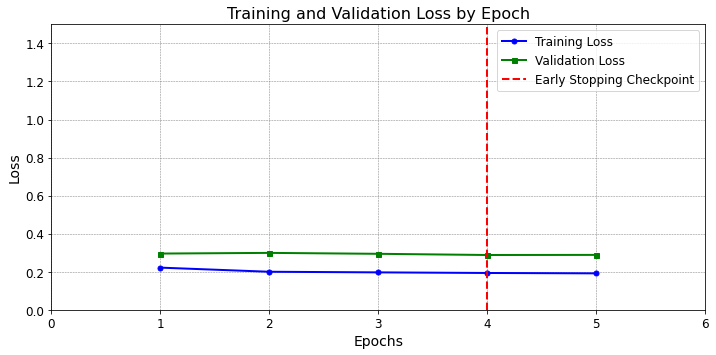

In [102]:
plot_losses(train_losses, valid_losses)

## Testing

### Load Best Model

In [157]:
def load_best_model(checkpoints_dir, based_on='loss', model_class=MultiModalModel, checkpoint="bert-base-cased", 
                    lstm_input_size=244, lstm_hidden_size=128, lstm_num_layers=1, dropout=0.1, static_input_size=30, 
                    static_hidden_size=20, static_drop_out=0.2, number_classes=2):
                    
    checkpoint_files = os.listdir(checkpoints_dir)
    best_file = None
    best_metric = float('inf') if based_on == 'loss' else float('-inf')

    for file in checkpoint_files:
        parts = file.replace('.pt', '').split('_')
        val_loss = float(parts[-1])
        val_auc  = float(parts[4])

        if based_on == 'loss' and val_loss < best_metric:
            best_metric = val_loss
            best_file = file
        elif based_on == 'auc' and val_auc > best_metric:
            best_metric = val_auc
            best_file = file

    if best_file is None:
        raise FileNotFoundError("No checkpoint files found!")

    print(f"Loading best model from {best_file} based on {based_on}...")
        
    best_model = model_class(checkpoint, 
                             lstm_input_size, 
                             lstm_hidden_size, 
                             lstm_num_layers, 
                             dropout, 
                             static_input_size, 
                             static_hidden_size, 
                             static_drop_out,
                             number_classes)

    checkpoint_path = os.path.join(checkpoints_dir, best_file)
    checkpoint = torch.load(checkpoint_path)
    
    best_model.load_state_dict(checkpoint['model_state_dict'])
    
    return best_model

In [158]:
checkpoints_dir = './checkpoints/LSTM_LLM_FF'
best_model = load_best_model(checkpoints_dir, 'auc') # 'auc', 'loss', 'f1'

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
best_model.to(device)

Loading best model from epoch_2_val_auc_0.8675_val_f1_0.3811_val_loss_0.2943.pt based on auc...


MultiModalModel(
  (llm): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_af

### Test Loop

In [159]:
def test_model(model, dataloader):
    
    model.eval()
    labels = []
    predictions = []
    
    test_progress_bar = tqdm(dataloader)
    
    for batch in test_progress_bar:
        batch = {k: v.to(device) for k, v in batch.items()}

        with torch.no_grad():
            outputs, _, _ = model(input_ids= batch['input_ids'],
                                  attention_mask= batch['attention_mask'],
                                  token_type_ids= batch['token_type_ids'],
                                  ehr_data= batch['ehr_data'],
                                  seq_lengths= batch['ehr_length'],
                                  static_data = batch['comor_data'])

        prediction = nn.Softmax(dim=1)(outputs)
        prediction = prediction.detach().cpu().numpy()
        prediction = prediction[:,1]

        label = batch["labels"]
        label = label.to('cpu').numpy()
        
        labels.extend(label)
        predictions.extend(prediction)
    
    labels = np.array(labels)
    predictions = np.array(predictions)
    
    return labels, predictions

In [160]:
true_labels, pred_probs = test_model(best_model, multi_test_loader)

  0%|          | 0/5757 [00:00<?, ?it/s]

### Calibration

In [161]:
def calibrate_probabilities(predicted_probabilities, true_labels):

    predicted_probabilities = np.asarray(predicted_probabilities)
    true_labels = np.asarray(true_labels)

    isotonic_regressor = IsotonicRegression(out_of_bounds='clip')
    isotonic_regressor.fit(predicted_probabilities, true_labels)

    calibrated_probabilities = isotonic_regressor.transform(predicted_probabilities)

    return isotonic_regressor

In [162]:
# true_labels_train, pred_probs_train = test_model(best_model, multi_train_loader)
# true_labels_valid, pred_probs_valid = test_model(best_model, multi_valid_loader)

# true_labels_tv = np.concatenate([true_labels_train, true_labels_valid], axis=0)
# pred_probs_tv  = np.concatenate([pred_probs_train,  pred_probs_valid],  axis=0)

# isotonic_regressor = calibrate_probabilities(pred_probs_tv, true_labels_tv)
# lstm_pred_probs = isotonic_regressor.transform(pred_probs)

### LLM Result

In [180]:
icustay_ids  = original_test_dataset['ICUSTAY_ID']
category_ids = original_test_dataset['CATEGORY']
row_ids = original_test_dataset['ROW_ID']

results_df = pd.DataFrame({'ICUSTAY_ID': icustay_ids,
                           'CATEGORY': category_ids,
                           'ROW_ID': row_ids,
                           'True_Label': true_labels,
                           'Predicted_Probability': pred_probs})

### Max

In [165]:
# notes_result_df = results_df.groupby(['ICUSTAY_ID', 'CATEGORY', 'ROW_ID']).max().reset_index()
# idx = results_df.groupby('ICUSTAY_ID')['Predicted_Probability'].idxmax()
# patients_result_df = results_df.loc[idx]

### Mean

In [181]:
notes_result_df = results_df.groupby(['ICUSTAY_ID', 'CATEGORY', 'ROW_ID']).mean().reset_index()
patients_result_df = notes_result_df[['ICUSTAY_ID', 'Predicted_Probability']].groupby('ICUSTAY_ID').max().reset_index()

### Patient Results

In [182]:
patients_result_df = patients_result_df.merge(test_result, on='ICUSTAY_ID', how='left')
patients_result_df = patients_result_df.reset_index(drop=True)
patients_result_df.head(3)

In [183]:
print(patients_result_df.shape)
print(patients_result_df.ICUSTAY_ID.nunique())

(8741, 7)
8741


In [184]:
note_true_labels_llm = notes_result_df['True_Label']
note_pred_probs_llm  = notes_result_df['Predicted_Probability']

patient_true_labels_llm = patients_result_df['ICU_EXPIRE_FLAG']
patient_pred_probs_llm  = patients_result_df['Predicted_Probability']

### ROC

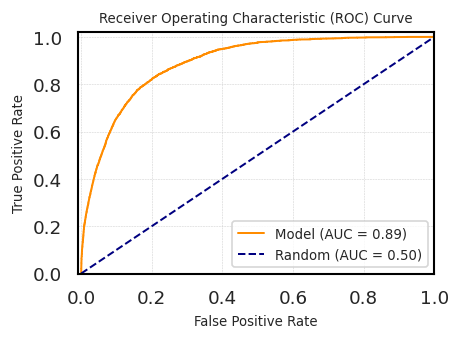

In [185]:
ROC_curve(note_true_labels_llm, note_pred_probs_llm)

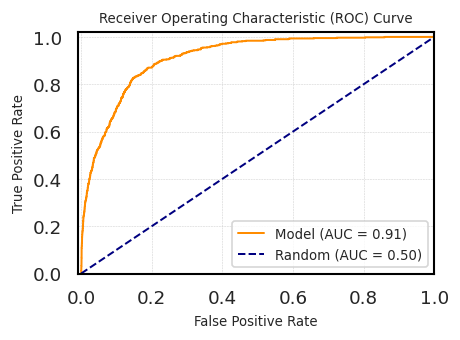

In [186]:
ROC_curve(patient_true_labels_llm, patient_pred_probs_llm)

### Precision - Recall

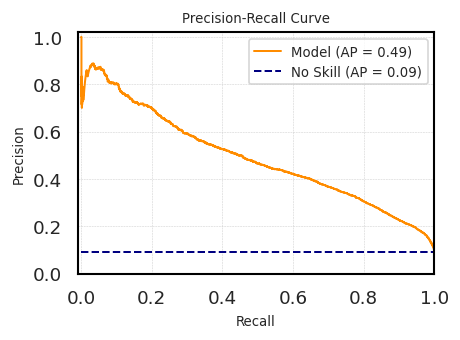

In [187]:
PRC_REC_curve(note_true_labels_llm, note_pred_probs_llm)

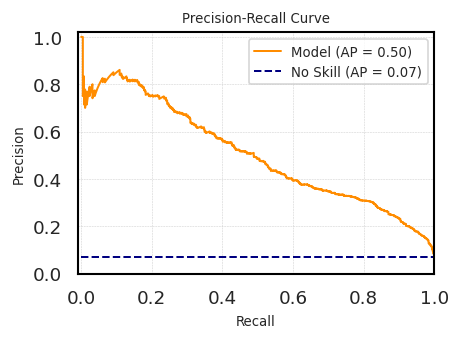

In [188]:
PRC_REC_curve(patient_true_labels_llm, patient_pred_probs_llm)

### Set Decision Threshold

In [191]:
decision_recall = 0.8

In [192]:
note_predicted_label_llm, note_decision_threshold = Prediction_Labels_Thresholding(note_true_labels_llm, 
                                                                                   note_pred_probs_llm, 
                                                                                   decision_recall)

notes_result_df['Predicted_Label'] = note_predicted_label_llm

Decision Threshold is:  0.22


In [193]:
patient_predicted_label_llm, patient_decision_threshold = Prediction_Labels_Thresholding(patient_true_labels_llm, 
                                                                                         patient_pred_probs_llm, 
                                                                                         decision_recall)

patients_result_df['Predicted_Label'] = patient_predicted_label_llm

Decision Threshold is:  0.45


### Confusion Matrix

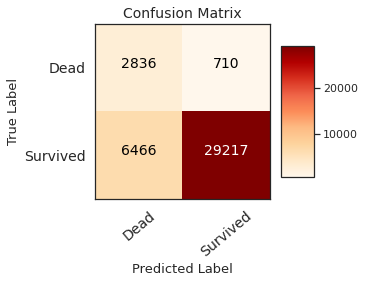

In [194]:
Confusion_Matrix(note_true_labels_llm, note_predicted_label_llm, classes = ['Dead', 'Survived'])

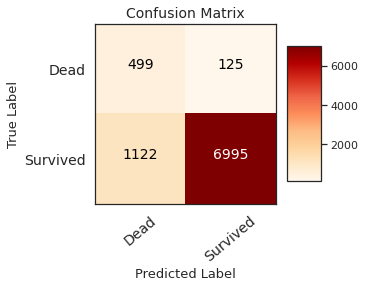

In [195]:
Confusion_Matrix(patient_true_labels_llm, patient_predicted_label_llm, classes = ['Dead', 'Survived'])

### Performance Metrics

In [148]:
metrics = performance_metric(note_true_labels_llm, note_pred_probs_llm)
metrics

{'ACC': 0.82,
 'PRC': 0.3,
 'REC': 0.8,
 'F1M': 0.44,
 'PPV': 0.3,
 'NPV': 0.98,
 'AUC': 0.89,
 'AP': 0.49,
 'MCC': 0.42,
 'THRSH': 0.18}

In [149]:
Performance_Metrics(note_true_labels_llm, note_predicted_label_llm, note_pred_probs_llm)

ACC =  0.82
PRC =  0.3
REC =  0.8
F1M =  0.44
PPV =  0.3
NPV =  0.98
SEN =  0.8
SPE =  0.82
FPR =  0.18
FNR =  0.2
FDR =  0.7
AUC =  0.89
AP  =  0.49
MCC =  0.42


In [150]:
metrics = performance_metric(patient_true_labels_llm, patient_pred_probs_llm)
metrics

{'ACC': 0.86,
 'PRC': 0.31,
 'REC': 0.8,
 'F1M': 0.45,
 'PPV': 0.31,
 'NPV': 0.98,
 'AUC': 0.91,
 'AP': 0.51,
 'MCC': 0.44,
 'THRSH': 0.42}

In [151]:
Performance_Metrics(patient_true_labels_llm, patient_predicted_label_llm, patient_pred_probs_llm)

ACC =  0.86
PRC =  0.31
REC =  0.8
F1M =  0.45
PPV =  0.31
NPV =  0.98
SEN =  0.8
SPE =  0.86
FPR =  0.14
FNR =  0.2
FDR =  0.69
AUC =  0.91
AP  =  0.51
MCC =  0.44


### Distribution of Prediction Probabilities

In [152]:
df_prediction_llm_alive = patients_result_df[patients_result_df['ICU_FLAG'] == 'Survived']
df_prediction_llm_dead  = patients_result_df[patients_result_df['ICU_FLAG'] == 'Dead']

### Alive Patients

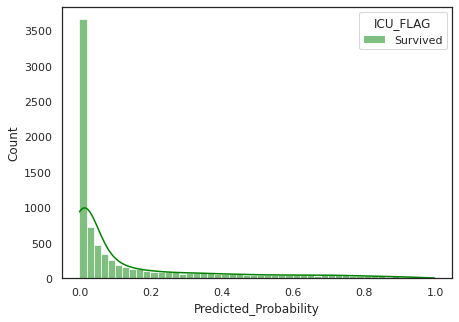

In [153]:
plt.figure(figsize=(7, 5))
sns.set(font_scale= 1)
sns.set_style(style='white')
sns.histplot(data=df_prediction_llm_alive, x='Predicted_Probability', kde=True, stat='count', bins=50, fill=True,
             legend=True, hue='ICU_FLAG', palette=['green'])
plt.show()

### Dead Patients

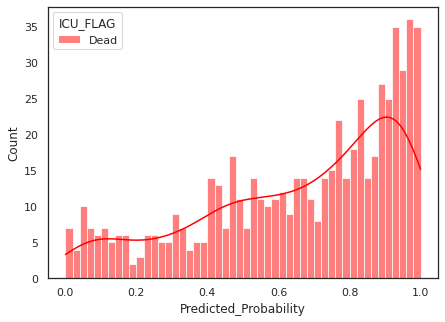

In [154]:
plt.figure(figsize=(7, 5))
sns.set(font_scale= 1)
sns.set_style(style='white')
sns.histplot(data=df_prediction_llm_dead, x='Predicted_Probability', kde=True, stat='count', bins=50, fill=True,
             legend=True, hue='ICU_FLAG', palette=['red'])
plt.show()

### Multimodal

ROC AUC:  0.88
PR  AUC:  0.49
                   ________________________
                  |  Classification Report |
                   ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
              precision    recall  f1-score   support

    Negative       0.98      0.80      0.88     33357
    Positive       0.29      0.80      0.42      3386

    accuracy                           0.80     36743
   macro avg       0.63      0.80      0.65     36743
weighted avg       0.91      0.80      0.83     36743

None


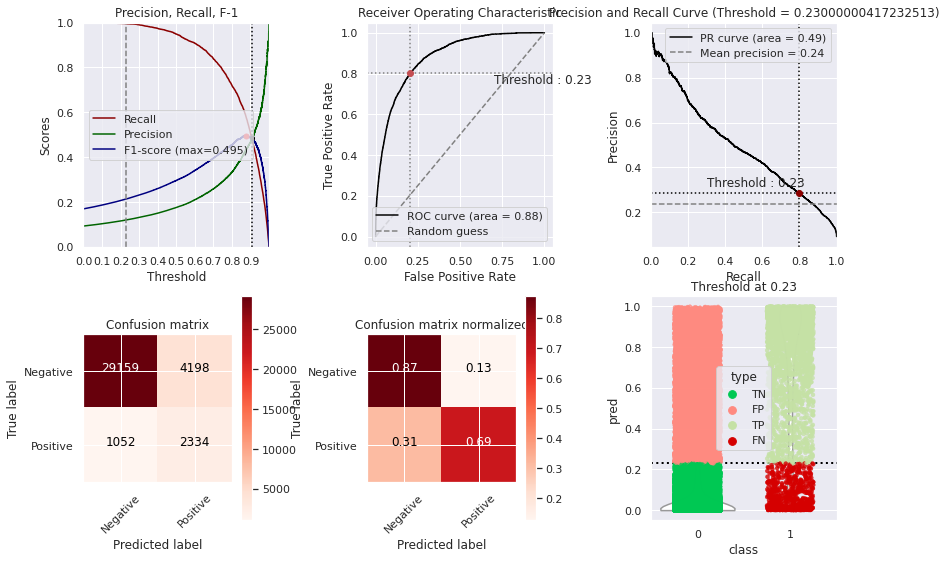

In [142]:
Binary_Classification_Performance(note_true_labels_llm, note_pred_probs_llm, note_decision_threshold)

ROC AUC:  0.9
PR  AUC:  0.5
                   ________________________
                  |  Classification Report |
                   ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
              precision    recall  f1-score   support

    Negative       0.98      0.83      0.90      7673
    Positive       0.27      0.80      0.40       612

    accuracy                           0.82      8285
   macro avg       0.62      0.81      0.65      8285
weighted avg       0.93      0.82      0.86      8285

None


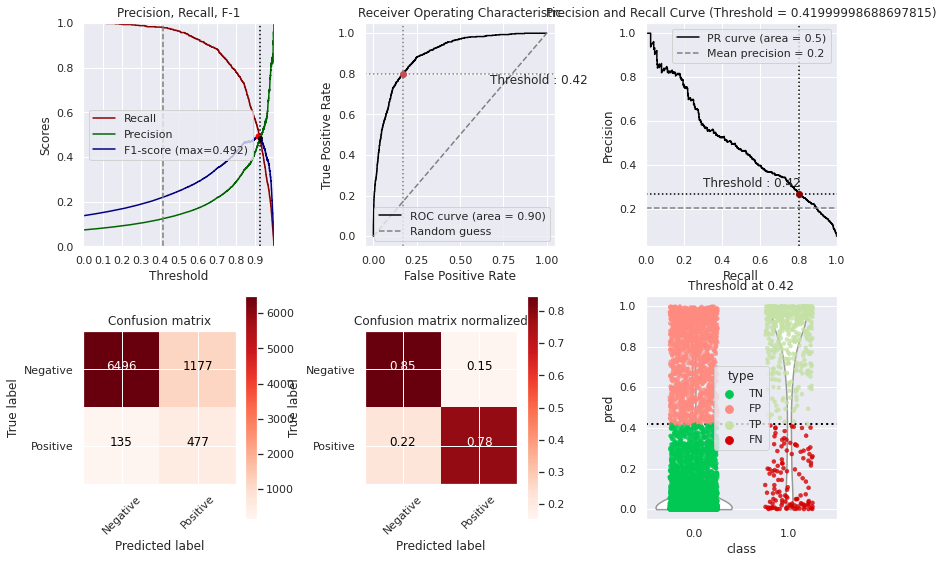

In [143]:
Binary_Classification_Performance(patient_true_labels_llm, patient_pred_probs_llm, patient_decision_threshold)

### Save Result

In [156]:
# patients_result_df.to_csv("./Results/LSTM_LLM_FF_Result.csv", index=False)
# patients_result_df.to_csv("./Results/LSTM_LLM_FF_Result_Cal.csv", index=False)

In [22]:
# patients_result_df = pd.read_csv("./Results/LSTM_LLM_FF_Result.csv")

### Bias & Fairness

In [23]:
patients_result_df.head(3)

### Read Race Dictionary

In [24]:
with open(race_path + 'race_dictionary.pkl', 'rb') as f:
    race_dictionary = pickle.load(f)

In [25]:
general_ethnicity_mapping = {
    
    'WHITE': 'White',
    'WHITE - RUSSIAN': 'White',
    'WHITE - BRAZILIAN': 'White',
    'WHITE - OTHER EUROPEAN': 'White',
    'WHITE - EASTERN EUROPEAN': 'White',
    'PORTUGUESE': 'White',
    
    'UNABLE TO OBTAIN': 'Other',
    'UNKNOWN/NOT SPECIFIED': 'Other',
    'PATIENT DECLINED TO ANSWER': 'Other',
    
    'OTHER': 'Other',
    'MIDDLE EASTERN': 'Other',
    'CARIBBEAN ISLAND': 'Other',
    'MULTI RACE ETHNICITY': 'Other',
    'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER': 'Other',
    
    'ASIAN': 'Asian',
    'ASIAN - THAI': 'Asian',
    'ASIAN - OTHER': 'Asian',
    'ASIAN - KOREAN': 'Asian',
    'ASIAN - CHINESE': 'Asian',
    'ASIAN - FILIPINO': 'Asian',
    'ASIAN - JAPANESE': 'Asian',
    'ASIAN - CAMBODIAN': 'Asian',
    'ASIAN - VIETNAMESE': 'Asian',
    'ASIAN - ASIAN INDIAN': 'Asian',
    
    'AMERICAN INDIAN/ALASKA NATIVE': 'Other',
    'AMERICAN INDIAN/ALASKA NATIVE FEDERALLY RECOGNIZED TRIBE': 'Other',
    
    'BLACK/AFRICAN': 'Black/African American',
    'BLACK/HAITIAN': 'Black/African American',
    'BLACK/CAPE VERDEAN': 'Black/African American',
    'BLACK/AFRICAN AMERICAN': 'Black/African American',
    
    'SOUTH AMERICAN': 'Hispanic/Latino',
    'HISPANIC OR LATINO': 'Hispanic/Latino',
    'HISPANIC/LATINO - CUBAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - MEXICAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - HONDURAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - DOMINICAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - COLOMBIAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - SALVADORAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - GUATEMALAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - PUERTO RICAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - CENTRAL AMERICAN (OTHER)': 'Hispanic/Latino'}

In [26]:
def replace_ethnicity_with_names(df, ethnicity_dict):
    
    inv_ethnicity_dict = {v: k for k, v in ethnicity_dict.items()}
    df['ETHNICITY'] = df['ETHNICITY'].map(inv_ethnicity_dict)
    
    return df

In [27]:
def categorize_ethnicity(df, new_mapping):
    
    df['ETHNICITY'] = df['ETHNICITY'].map(new_mapping)
    
    return df

In [28]:
demog_col = ['ICUSTAY_ID', 'GENDER', 'AGE', 'ETHNICITY']
df_demog = patients_result_df[demog_col].copy()

df_demog = replace_ethnicity_with_names(df_demog, race_dictionary)
df_demog = categorize_ethnicity(df_demog, general_ethnicity_mapping)

df_demog = df_demog.drop_duplicates().reset_index(drop=True)
df_demog.loc[df_demog.GENDER == 1.0, 'GENDER'] = 'Male'
df_demog.loc[df_demog.GENDER == 2.0, 'GENDER'] = 'Female'

bins = [-np.inf, 45, 60, 76, np.inf]
labels = ['Under 45', '46-60',  '61-75', 'Over 76']
df_demog['agegroup'] = pd.cut(df_demog['AGE'], bins=bins, labels=labels, right=False)
df_demog = df_demog.drop(columns= 'AGE')

In [29]:
df_demog.head(3)

### Multimodal Result Frame

In [30]:
MULTI_df_bias = patients_result_df[['ICUSTAY_ID', 'Predicted_Label', 'ICU_EXPIRE_FLAG']]
MULTI_df_bias = pd.merge(MULTI_df_bias, df_demog, on=['ICUSTAY_ID'], how='left')

MULTI_df_bias.rename(columns={'GENDER': 'sex',
                              'ETHNICITY' : 'ethnic',
                              'ICUSTAY_ID': 'entity_id',
                              'Predicted_Label': 'score', 
                              'ICU_EXPIRE_FLAG': 'label_value'}, inplace=True)

MULTI_df_bias['sex']  = MULTI_df_bias.sex.astype(str)
MULTI_df_bias['score'] = MULTI_df_bias.score.astype(int)
MULTI_df_bias['ethnic'] = MULTI_df_bias.ethnic.astype(str)
MULTI_df_bias['agegroup'] = MULTI_df_bias.agegroup.astype(str)
MULTI_df_bias.head(3)

In [31]:
g = Group()

MULTItab, _ = g.get_crosstabs(MULTI_df_bias, attr_cols=['sex', 'agegroup', 'ethnic'])
MULTItab['model_id'] = 'EHR + Notes'
MULTItab.head(3)

,model_id,score_threshold,k,attribute_name,attribute_value,accuracy,tpr,tnr,for,fdr,...,pprev,fp,fn,tn,tp,group_label_pos,group_label_neg,group_size,total_entities,prev
0,EHR + Notes,binary 0/1,1602,sex,Female,0.846623,0.781818,0.851714,0.019730,0.707084,...,0.194437,519,60,2981,215,275,3500,3775,8741,0.072848
1,EHR + Notes,binary 0/1,1602,sex,Male,0.869311,0.813754,0.873511,0.015861,0.672811,...,0.174789,584,65,4033,284,349,4617,4966,8741,0.070278
2,EHR + Notes,binary 0/1,1602,agegroup,46-60,0.886364,0.820755,0.889908,0.010765,0.712871,...,0.146518,216,19,1746,87,106,1962,2068,8741,0.051257


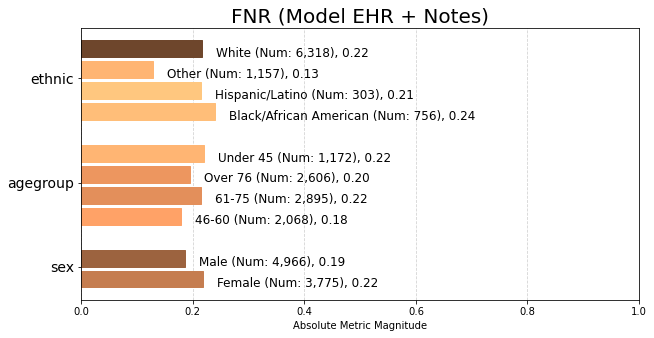

In [32]:
aqp = Plot()

a = aqp.plot_group_metric(MULTItab, 'fnr', min_group_size=0.01)

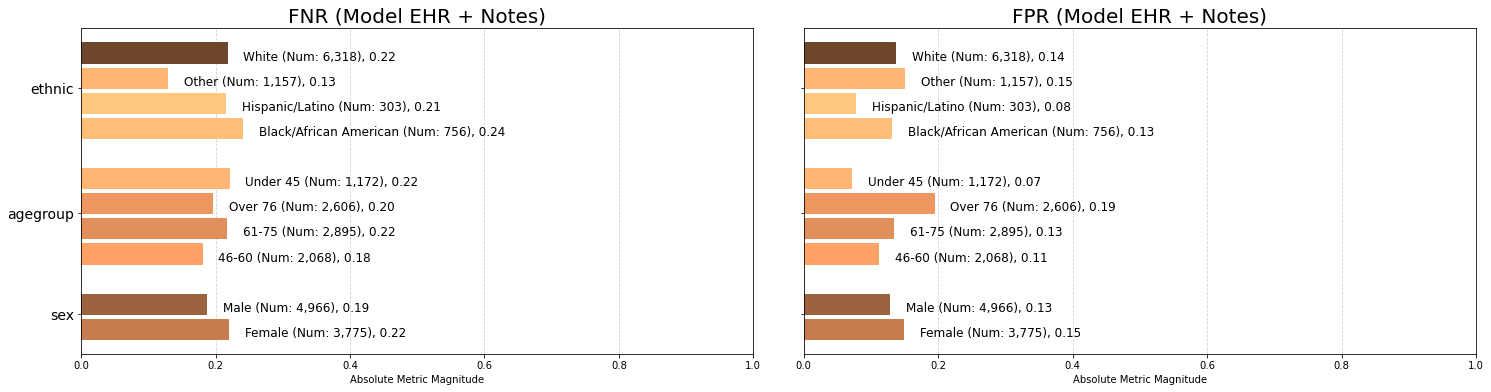

<Figure size 432x288 with 0 Axes>

In [33]:
a = aqp.plot_group_metric_all(MULTItab, metrics=['fnr','fpr'], ncols=2, min_group_size=0.01)

In [34]:
b = Bias()

sex_ref = 'Male' 
age_ref = '61-75'
ethnic_ref = 'Black/African American'

In [35]:
bdf = b.get_disparity_predefined_groups(MULTItab, original_df=MULTI_df_bias, alpha=0.01, mask_significance=True,
                                        ref_groups_dict={'ethnic':ethnic_ref,'sex':sex_ref,'agegroup':age_ref})
majority_bdf = b.get_disparity_major_group(MULTItab, original_df=MULTI_df_bias, mask_significance=True, alpha=0.01)
min_metric_bdf = b.get_disparity_min_metric(df=MULTItab, original_df=MULTI_df_bias, alpha=0.01)
bdf.head(3)

,model_id,score_threshold,k,attribute_name,attribute_value,accuracy,tpr,tnr,for,fdr,...,ppr_ref_group_value,pprev_ref_group_value,precision_ref_group_value,fdr_ref_group_value,for_ref_group_value,fpr_ref_group_value,fnr_ref_group_value,tpr_ref_group_value,tnr_ref_group_value,npv_ref_group_value
0,EHR + Notes,binary 0/1,1602,sex,Female,0.846623,0.781818,0.851714,0.019730,0.707084,...,Male,Male,Male,Male,Male,Male,Male,Male,Male,Male
1,EHR + Notes,binary 0/1,1602,sex,Male,0.869311,0.813754,0.873511,0.015861,0.672811,...,Male,Male,Male,Male,Male,Male,Male,Male,Male,Male
2,EHR + Notes,binary 0/1,1602,agegroup,46-60,0.886364,0.820755,0.889908,0.010765,0.712871,...,61-75,61-75,61-75,61-75,61-75,61-75,61-75,61-75,61-75,61-75


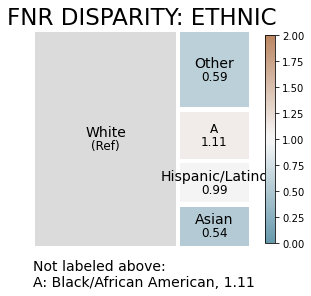

In [36]:
aqp.plot_disparity(majority_bdf, group_metric='fnr_disparity', attribute_name='ethnic', significance_alpha=0.05)

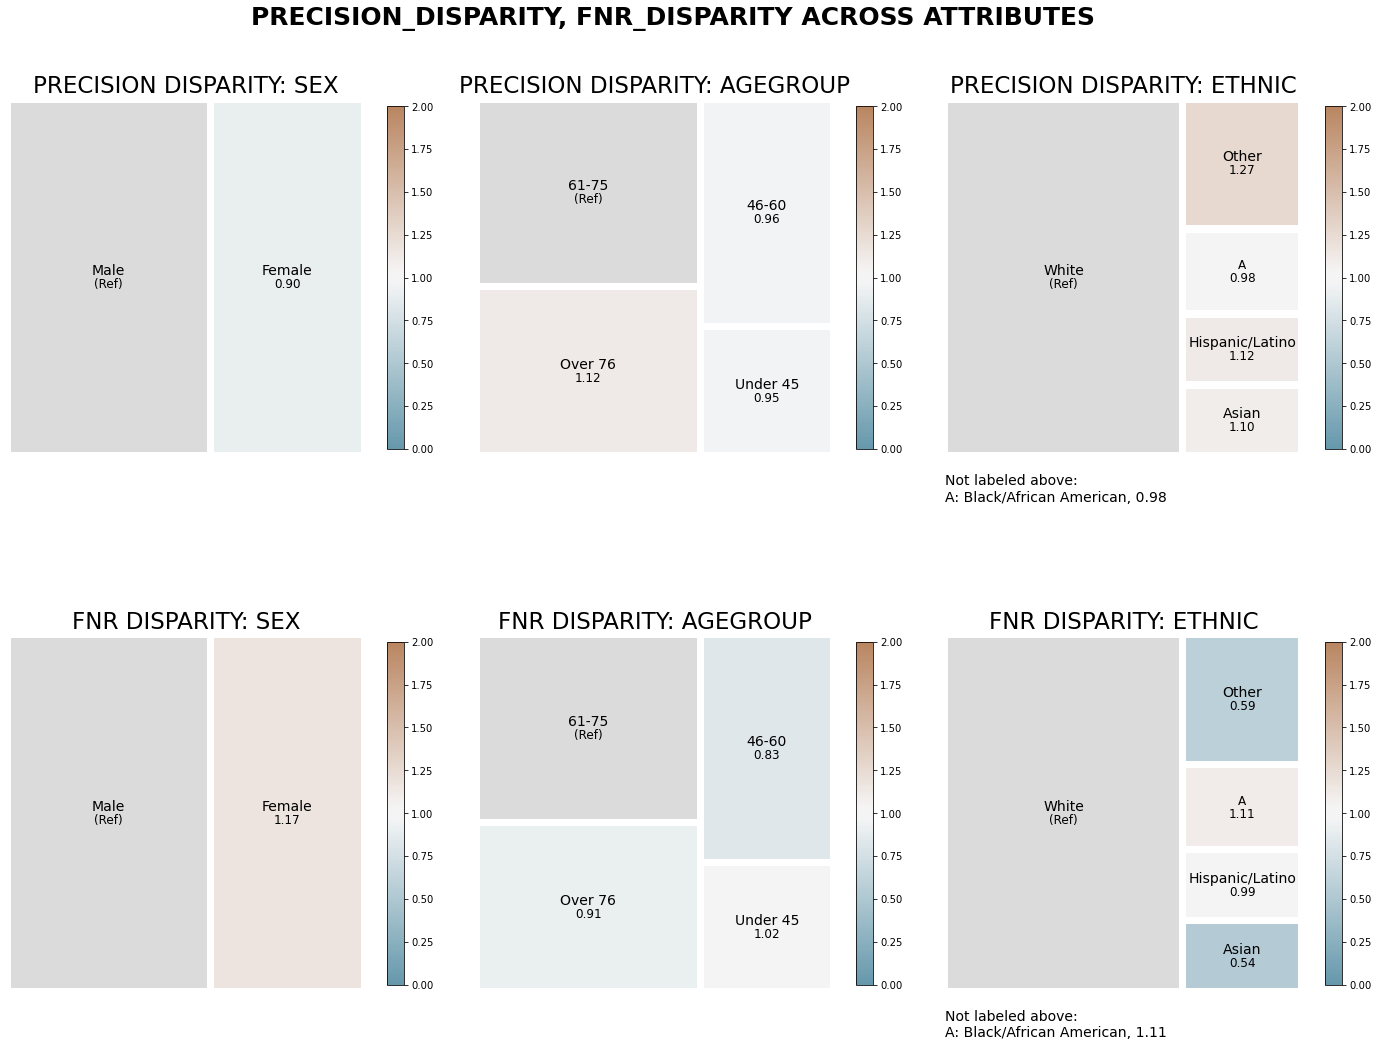

In [37]:
a = aqp.plot_disparity_all(majority_bdf, metrics=['precision_disparity', 'fnr_disparity'], significance_alpha=0.05)

In [38]:
f = Fairness()

fdf = f.get_group_value_fairness(bdf)
gaf = f.get_group_attribute_fairness(fdf)
fdf.head(3)

,model_id,score_threshold,k,attribute_name,attribute_value,accuracy,tpr,tnr,for,fdr,...,FNR Parity,TPR Parity,TNR Parity,NPV Parity,Precision Parity,TypeI Parity,TypeII Parity,Equalized Odds,Unsupervised Fairness,Supervised Fairness
0,EHR + Notes,binary 0/1,1602,sex,Female,0.846623,0.781818,0.851714,0.019730,0.707084,...,True,True,True,True,True,True,True,True,True,True
1,EHR + Notes,binary 0/1,1602,sex,Male,0.869311,0.813754,0.873511,0.015861,0.672811,...,True,True,True,True,True,True,True,True,True,True
2,EHR + Notes,binary 0/1,1602,agegroup,46-60,0.886364,0.820755,0.889908,0.010765,0.712871,...,True,True,True,True,True,True,False,True,False,False


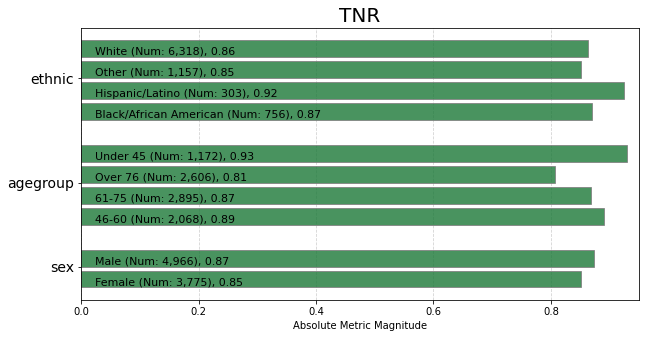

In [47]:
a = aqp.plot_fairness_group(fdf, group_metric='tnr', min_group_size=0.01, ax_lim=0.95, title=True)

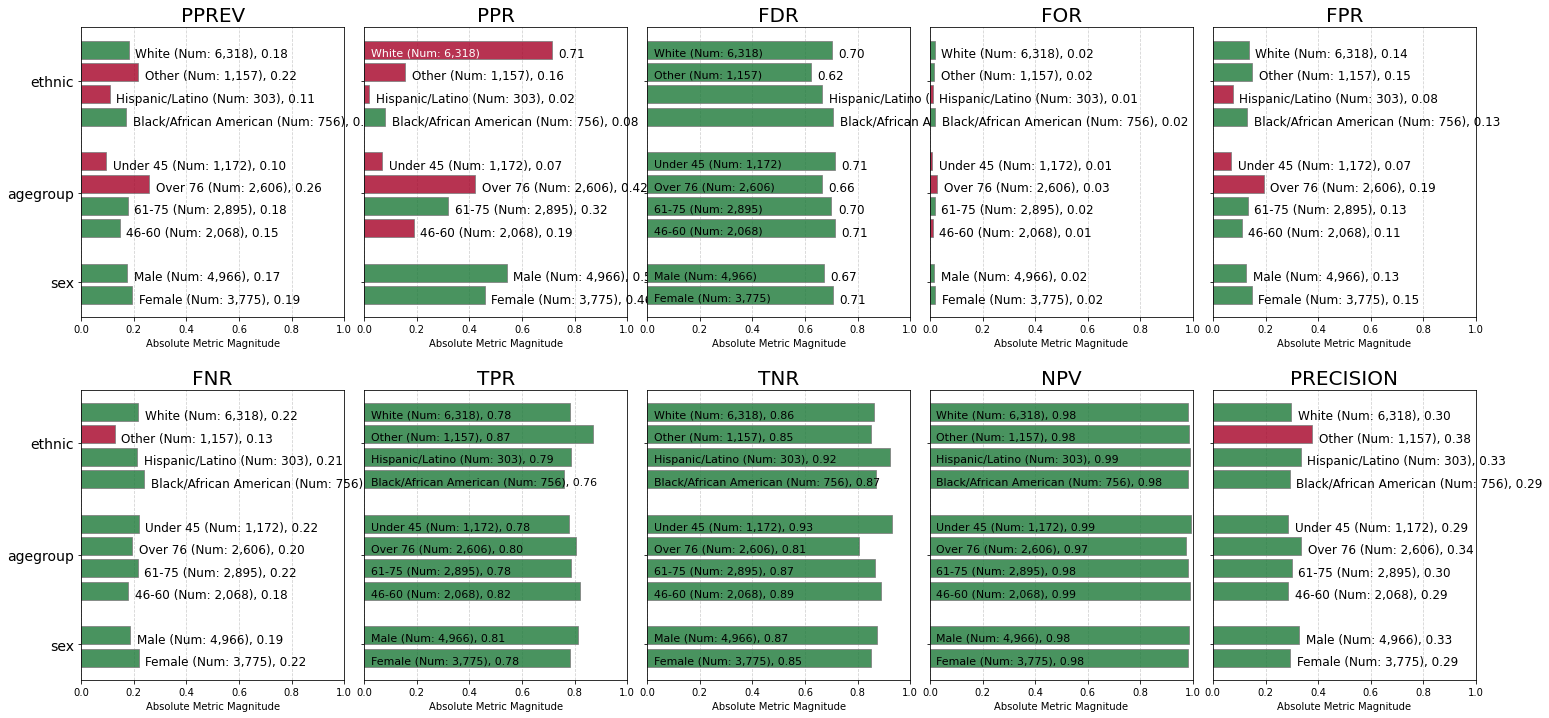

<Figure size 432x288 with 0 Axes>

In [40]:
a = aqp.plot_fairness_group_all(fdf, ncols=5, metrics = "all", min_group_size=0.01)

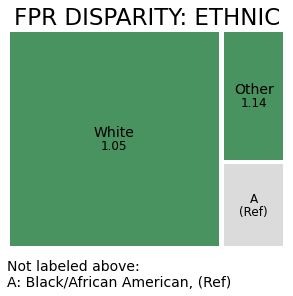

In [41]:
a = aqp.plot_fairness_disparity(fdf, group_metric='fpr', attribute_name='ethnic', min_group_size=0.02, significance_alpha=0.05)

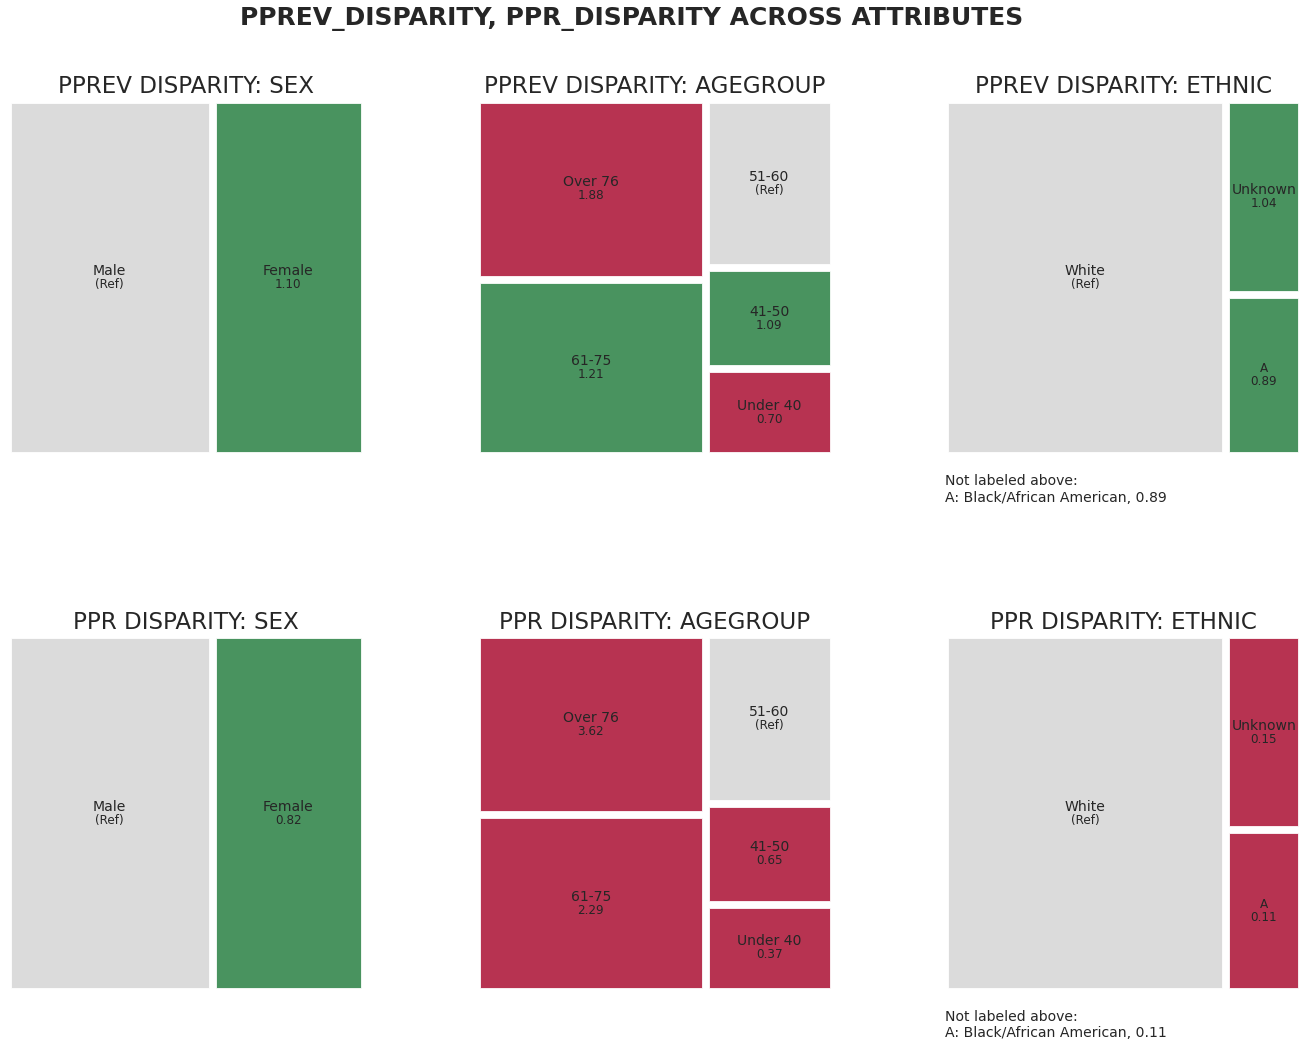

In [165]:
a = aqp.plot_fairness_disparity_all(fdf, metrics=['pprev_disparity', 'ppr_disparity'],  min_group_size=0.02, significance_alpha=0.05)

### Check Model Output

In [188]:
batch_size = 1

In [149]:
multi_test_loader  = DataLoader(multi_test_dataset,  batch_size=batch_size, shuffle=False, 
                                collate_fn=multimodal_collate_fn)

In [150]:
test_dataloader_iter = iter(multi_test_loader)

In [151]:
batch = next(test_dataloader_iter)
batch = {k: v.to(device) for k, v in batch.items()}

In [154]:
with torch.no_grad():
    model_output, hidden_states, attentions = best_model(input_ids= batch['input_ids'],
                                                          attention_mask= batch['attention_mask'],
                                                          token_type_ids= batch['token_type_ids'],
                                                          ehr_data= batch['ehr_data'],
                                                          seq_lengths= batch['ehr_length'])

In [155]:
prediction = nn.Softmax(dim=1)(model_output)
print(prediction)
print(batch['labels'])

tensor([[0.6534, 0.3466]], device='cuda:0')
tensor([0], device='cuda:0')


In [156]:
print(len(hidden_states))

print("Hidden state size (per layer):  ", hidden_states[0].shape)
print("Attention head size (per layer):", attentions[0].shape)

print("Number of Layers:", len(attentions))
print("Number of Heads: ", len(attentions[0][0]))

13
Hidden state size (per layer):   torch.Size([1, 105, 768])
Attention head size (per layer): torch.Size([1, 12, 105, 105])
Number of Layers: 12
Number of Heads:  12


In [157]:
sample_number = 0
layer_number  = 6

In [158]:
def plot_relevant_attention_heads(attentions, attention_mask, all_indices, sample_number, layer_number, 
                                  seq_length=None, token_vis=False):
    
    if seq_length == None:
        seq_length = torch.sum(attention_mask[sample_number]).item()
    
    indices = all_indices[sample_number][:seq_length]
    all_tokens = tokenizer.convert_ids_to_tokens(indices)

    layer_attentions = attentions[layer_number][sample_number]

    num_heads = layer_attentions.size(0)

    fig, axes = plt.subplots(num_heads // 4, 4, figsize=(30, num_heads * 2)) 

    for i in range(num_heads):
        ax = axes.flatten()[i]
        attention_slice = layer_attentions[i, :seq_length, :seq_length].detach().cpu().numpy()
        ax.imshow(attention_slice, cmap='viridis', aspect='equal')
        ax.set_title(f'Head {i + 1}')
        ax.set_xlabel('Key Positions')
        ax.set_ylabel('Query Positions')
        ax.set_xlim(0, seq_length - 1)
        ax.set_ylim(seq_length - 1, 0)  
        
        if token_vis:
            fontdict = {'fontsize': 10}
            ax.set_xticks(range(len(all_tokens)))
            ax.set_yticks(range(len(all_tokens)))
            ax.set_xticklabels(all_tokens, fontdict=fontdict, rotation=90)
            ax.set_yticklabels(all_tokens, fontdict=fontdict)
        
    plt.tight_layout()
    plt.show()

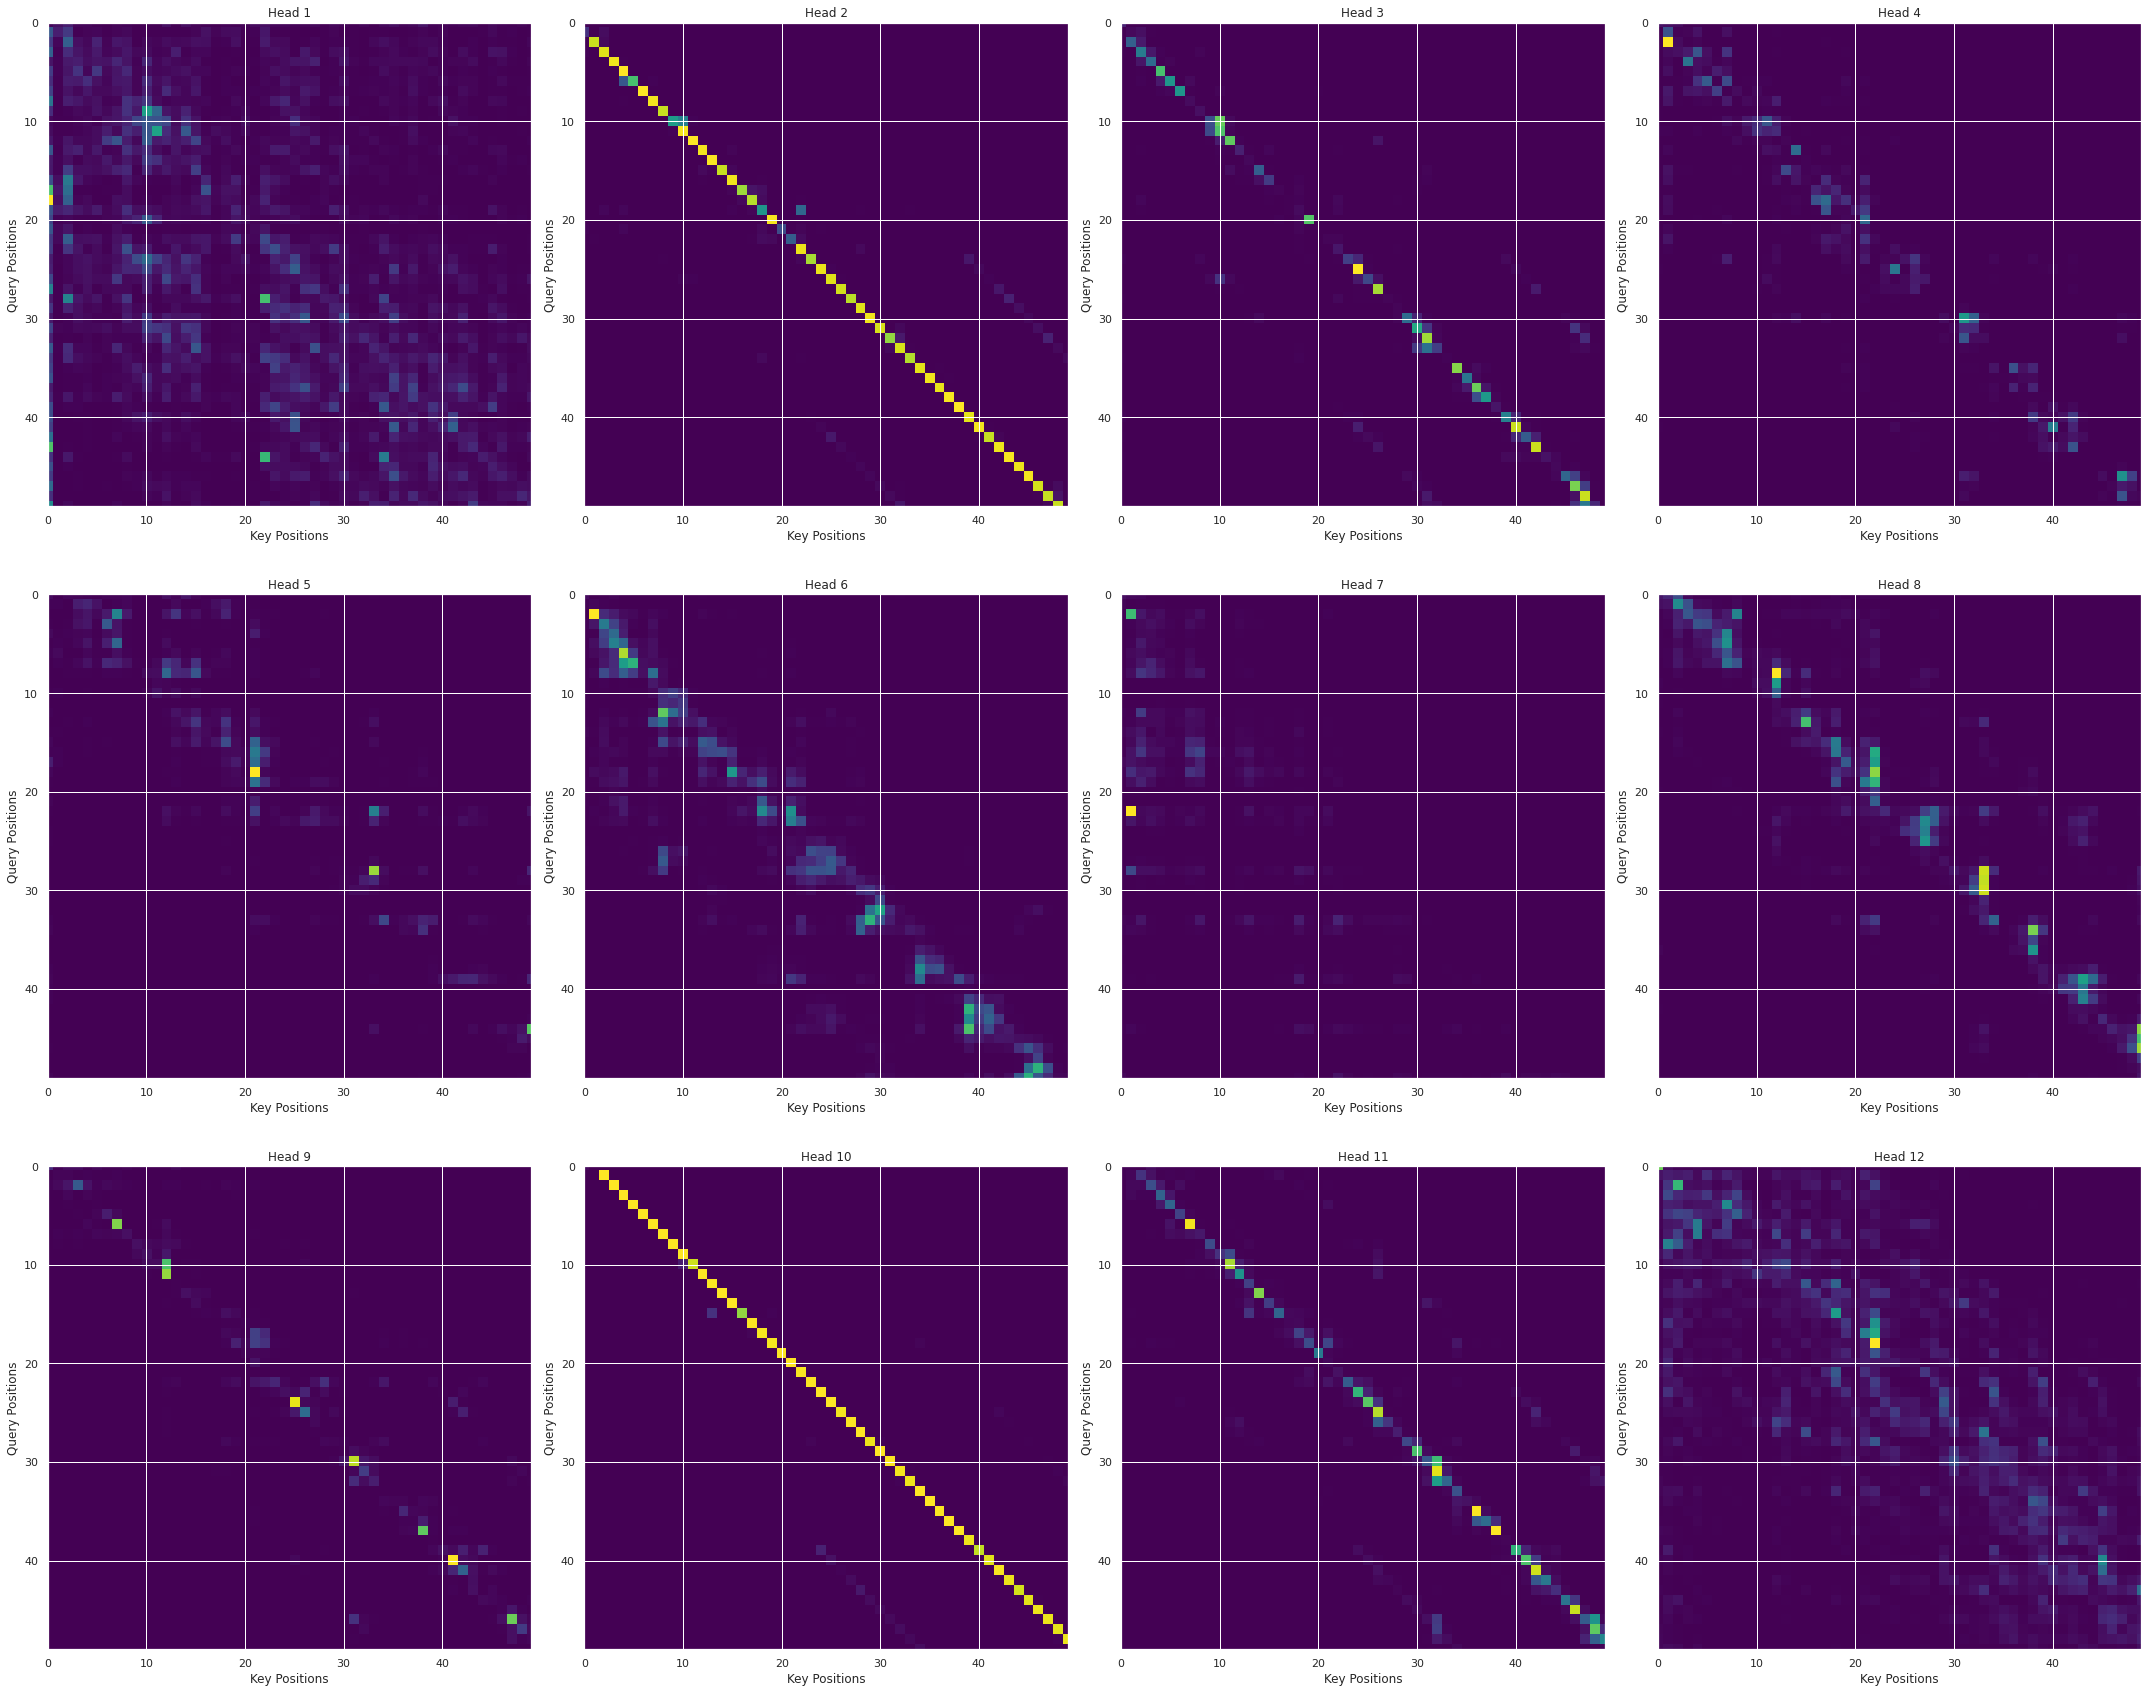

In [159]:
plot_relevant_attention_heads(attentions, batch['attention_mask'], batch['input_ids'],
                              sample_number=sample_number, layer_number=layer_number, 
                              seq_length=50, token_vis=False)

In [160]:
batch = {k: v.to('cpu').numpy() for k, v in batch.items()}

In [161]:
tokens = tokenizer.convert_ids_to_tokens(batch['input_ids'][0])
print(tokens)

## Interpretation

In [162]:
batch_size = 1

In [163]:
multi_test_loader  = DataLoader(multi_test_dataset,  batch_size=batch_size, shuffle=False, 
                                collate_fn=multimodal_collate_fn)

In [164]:
test_dataloader_iter = iter(multi_test_loader)

In [165]:
batch = next(test_dataloader_iter)
batch = {k: v.to(device) for k, v in batch.items()}

In [168]:
with torch.no_grad():
    model_output, hidden_states, attentions = best_model(input_ids= batch['input_ids'],
                                                         attention_mask= batch['attention_mask'],
                                                         token_type_ids= batch['token_type_ids'],
                                                         ehr_data= batch['ehr_data'],
                                                         seq_lengths= batch['ehr_length'])

In [169]:
tokens = tokenizer.convert_ids_to_tokens(batch['input_ids'][0])

In [170]:
num_tokens_to_keep = 15

truncated_tokens = tokens[:num_tokens_to_keep]
truncated_tokens_attentions = [layer[:, :, :num_tokens_to_keep, :num_tokens_to_keep] for layer in attentions]

In [171]:
head_view(truncated_tokens_attentions, truncated_tokens)

In [172]:
model_view(truncated_tokens_attentions, truncated_tokens)

In [173]:
def aggregate_tokens_and_attentions(tokens, attentions):
 
    word_tokens = []
    token_to_word = []
    
    for i, token in enumerate(tokens):
        if token.startswith("##"):
            word_tokens[-1] += token[2:] 
            token_to_word.append(len(word_tokens) - 1)  
        else:
            word_tokens.append(token)
            token_to_word.append(len(word_tokens) - 1)  

    num_words = len(word_tokens)
    num_heads = attentions[0].size(1) 

    new_attentions = torch.zeros((len(attentions), num_heads, num_words, num_words))

    for layer_idx, layer in enumerate(attentions):
        for head_idx in range(num_heads):
            
            head_attention = layer[0, head_idx]  
            new_head = torch.zeros((num_words, num_words), device=head_attention.device)
            
            for i in range(len(tokens)):
                for j in range(len(tokens)):
                    orig_i = token_to_word[i]
                    orig_j = token_to_word[j]
                    new_head[orig_i, orig_j] += head_attention[i, j] 

            new_attentions[layer_idx, head_idx] = new_head
            
    new_attentions = [layer.unsqueeze(0) for layer in new_attentions]

    return word_tokens, new_attentions

In [174]:
word_tokens, new_attentions = aggregate_tokens_and_attentions(tokens, attentions)

In [175]:
num_words_to_keep = 15

truncated_words = word_tokens[:num_words_to_keep]
truncated_words_attentions = [layer[:, :, :num_words_to_keep, :num_words_to_keep] for layer in new_attentions]

In [176]:
head_view(truncated_words_attentions, truncated_words)

In [177]:
model_view(truncated_words_attentions, truncated_words)

### Input-Output Captum Interpretation

In [235]:
best_model.eval()
best_model.zero_grad()

In [236]:
batch_size = 1

In [237]:
multi_test_loader  = DataLoader(multi_test_dataset,  batch_size=batch_size, shuffle=False, 
                                collate_fn=multimodal_collate_fn)

In [238]:
test_dataloader_iter = iter(multi_test_loader)

In [239]:
batch = next(test_dataloader_iter)

batch = {k: v.to(device) for k, v in batch.items()}

In [240]:
model_input = best_model.llm.embeddings

In [243]:
def multimodal_model_forward(input_ids, attention_mask, token_type_ids, ehr_data, seq_lengths):
    
    model_output, _, _ = best_model(input_ids=input_ids,
                                    attention_mask=attention_mask,
                                    token_type_ids=token_type_ids,
                                    ehr_data=ehr_data,
                                    seq_lengths=seq_lengths)
    
    return model_output[0]

In [244]:
lig = LayerIntegratedGradients(multimodal_model_forward, model_input)

In [245]:
def construct_multimodal_input_and_baseline(batch):
    
    cls_token_id = tokenizer.cls_token_id
    sep_token_id = tokenizer.sep_token_id  
    baseline_token_id = tokenizer.pad_token_id

    input_ids = batch['input_ids']  
    baseline_input_ids = input_ids.clone().detach()
    baseline_input_ids[:, 1:-1] = baseline_token_id
    baseline_input_ids[:, 0]  = cls_token_id  
    baseline_input_ids[:, -1] = sep_token_id 
 
    ehr_data = batch['ehr_data']
    baseline_ehr_data = torch.zeros_like(ehr_data)
    ehr_length = batch['ehr_length'] 
    
    attention_mask = batch['attention_mask']
    baseline_attention_mask = torch.zeros_like(attention_mask)
    
    token_type_ids = batch['token_type_ids']
    baseline_token_type_ids = torch.zeros_like(token_type_ids)
        
    token_list = tokenizer.convert_ids_to_tokens(input_ids[0])

    return (input_ids, attention_mask, token_type_ids, ehr_data, ehr_length), (baseline_input_ids, baseline_attention_mask, baseline_token_type_ids, baseline_ehr_data, ehr_length), token_list

In [246]:
inputs, baselines, all_tokens = construct_multimodal_input_and_baseline(batch)

In [247]:
attributions, delta = lig.attribute(inputs=(inputs),
                                    baselines= (baselines),
                                    return_convergence_delta=True,
                                    internal_batch_size=1,
                                    n_steps=100)

In [248]:
def summarize_attributions(attributions):

    attributions = attributions.sum(dim=-1).squeeze(0)
    attributions = attributions / torch.norm(attributions)
    
    return attributions

In [249]:
attributions_sum = summarize_attributions(attributions)

In [250]:
def words_attributions_aggregation(all_tokens, attributions_sum):
    
    word_attributions = []
    aggregated_tokens = []
    aggregated_attributions = 0.0
    current_word = ""

    for token, attribution in zip(all_tokens, attributions_sum.tolist()):

        if token.startswith("##"):
            current_word += token[2:]  
            aggregated_attributions += attribution  
        else:
            if current_word:
                aggregated_tokens.append(current_word)
                word_attributions.append(aggregated_attributions)
            current_word = token
            aggregated_attributions = attribution
            
    if current_word:
        aggregated_tokens.append(current_word)
        word_attributions.append(aggregated_attributions)

    word_attributions = torch.tensor(word_attributions, dtype=attributions_sum.dtype)
    
    return aggregated_tokens, word_attributions

In [251]:
aggregated_tokens, word_attributions = words_attributions_aggregation(all_tokens, attributions_sum)

In [253]:
model_output, hidden_states, attentions = best_model(input_ids= batch['input_ids'],
                                                     attention_mask= batch['attention_mask'],
                                                     token_type_ids= batch['token_type_ids'],
                                                     ehr_data= batch['ehr_data'],
                                                     seq_lengths= batch['ehr_length'])

predictions = nn.Softmax(dim=1)(model_output)
pred_prob   = torch.max(predictions)
pred_class  = torch.argmax(predictions).cpu().numpy()

In [254]:
input_ids = batch['input_ids']

raw_texts = []
for ids in input_ids:
    text = tokenizer.decode(ids, skip_special_tokens=True, clean_up_tokenization_spaces=True)
    raw_texts.append(text)

In [255]:
token_score_vis = viz.VisualizationDataRecord(word_attributions= attributions_sum,
                                                  pred_prob = pred_prob,
                                                  pred_class= pred_class,
                                                  true_class= batch['labels'][0],
                                                  attr_class= raw_texts[0],
                                                  attr_score= attributions_sum.sum(),       
                                                  raw_input_ids= all_tokens,
                                                  convergence_score= delta)

viz.visualize_text([token_score_vis])
plt.show()

In [256]:
word_score_vis = viz.VisualizationDataRecord(word_attributions= word_attributions,
                                             pred_prob = pred_prob,
                                             pred_class= pred_class,
                                             true_class= batch['labels'][0],  
                                             attr_class= raw_texts[0],  
                                             attr_score= word_attributions.sum(),
                                             raw_input_ids= aggregated_tokens,  
                                             convergence_score= delta)
viz.visualize_text([word_score_vis])
plt.show()

### Layer Captum Interpretation

In [257]:
device = 'cpu'
best_model.to(device)

MultiModalModel(
  (llm): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_af

In [258]:
best_model.eval()
best_model.zero_grad()

In [259]:
batch_size = 1

In [260]:
multi_test_loader  = DataLoader(multi_test_dataset,  batch_size=batch_size, shuffle=False, 
                                collate_fn=multimodal_collate_fn)

In [261]:
test_dataloader_iter = iter(multi_test_loader)

In [262]:
batch = next(test_dataloader_iter)

batch = {k: v.to(device) for k, v in batch.items()}

In [263]:
def construct_multimodal_input_and_baseline(batch):
    
    cls_token_id = tokenizer.cls_token_id
    sep_token_id = tokenizer.sep_token_id  
    baseline_token_id = tokenizer.pad_token_id

    input_ids = batch['input_ids']  
    baseline_input_ids = input_ids.clone().detach()
    baseline_input_ids[:, 1:-1] = baseline_token_id
    baseline_input_ids[:, 0]  = cls_token_id  
    baseline_input_ids[:, -1] = sep_token_id 
 
    ehr_data = batch['ehr_data']
    baseline_ehr_data = torch.zeros_like(ehr_data)
    ehr_length = batch['ehr_length'] 
    
    attention_mask = batch['attention_mask']
    baseline_attention_mask = torch.zeros_like(attention_mask)
    
    token_type_ids = batch['token_type_ids']
    baseline_token_type_ids = torch.zeros_like(token_type_ids)
        
    token_list = tokenizer.convert_ids_to_tokens(input_ids[0])

    return (input_ids, attention_mask, token_type_ids, ehr_data, ehr_length), (baseline_input_ids, baseline_attention_mask, baseline_token_type_ids, baseline_ehr_data, ehr_length), token_list

In [264]:
inputs, baselines, all_tokens = construct_multimodal_input_and_baseline(batch)

In [265]:
def construct_input_ref_pos_id_pair(input_ids):
    
    seq_length = input_ids.size(1)
    
    position_ids = torch.arange(seq_length, dtype=torch.long, device=device)
    ref_position_ids = torch.zeros(seq_length, dtype=torch.long, device=device)

    position_ids = position_ids.unsqueeze(0).expand_as(input_ids)
    ref_position_ids = ref_position_ids.unsqueeze(0).expand_as(input_ids)
    
    return position_ids, ref_position_ids

In [266]:
position_ids, ref_position_ids = construct_input_ref_pos_id_pair(inputs[0])

In [267]:
def construct_whole_llm_embeddings(input_ids, token_type_ids=None, position_ids=None, 
                                   ref_input_ids=None, ref_token_type_ids=None, ref_position_ids=None):
                                    
    input_embeddings = best_model.llm.embeddings(input_ids, token_type_ids=token_type_ids, position_ids=position_ids)
    ref_input_embeddings = best_model.llm.embeddings(ref_input_ids, token_type_ids=ref_token_type_ids, position_ids=ref_position_ids)
    
    return input_embeddings, ref_input_embeddings

In [268]:
input_embeddings, ref_input_embeddings = construct_whole_llm_embeddings(input_ids= inputs[0],
                                                                        token_type_ids= inputs[2],
                                                                        position_ids= position_ids,
                                                                        ref_input_ids= baselines[0],
                                                                        ref_token_type_ids= baselines[2],
                                                                        ref_position_ids= ref_position_ids)

In [269]:
def summarize_attributions(attributions):

    attributions = attributions.sum(dim=-1).squeeze(0)
    attributions = attributions / torch.norm(attributions)
    
    return attributions

In [270]:
def multimodal_forward_func(input_emb, attention_mask=None, token_type_ids=None, ehr_data=None, seq_lengths=None):

    llm_output = best_model.llm(inputs_embeds=input_emb, attention_mask=attention_mask, token_type_ids=token_type_ids)

    llm_pooled_output = llm_output.pooler_output 
    llm_pooled_output = best_model.llm_head(llm_pooled_output)
    
    seq_lengths = seq_lengths.to('cpu').long() 
    
    packed_input = pack_padded_sequence(ehr_data, seq_lengths, batch_first=True, enforce_sorted=False)
    
    lstm_output, (hidden_state, cell_state) =  best_model.lstm(packed_input) 
    
    lstm_output = torch.cat((hidden_state[-2], hidden_state[-1]), dim=1)
    lstm_output = best_model.lstm_head(lstm_output)
    
    combined_features = torch.cat([llm_pooled_output, lstm_output], dim=1)

    logits = best_model.classification_head(combined_features)
    
    return logits[:, 1] 

In [273]:
layer_attrs = []
layer_attrs_dist = []

for i in range(best_model.llm.config.num_hidden_layers):
    
    lc = LayerConductance(multimodal_forward_func, best_model.llm.encoder.layer[i])
    
    layer_attributions = lc.attribute(inputs=input_embeddings,
                                      baselines=ref_input_embeddings,
                                      additional_forward_args=(batch['attention_mask'], 
                                                               batch['token_type_ids'], 
                                                               batch['ehr_data'], 
                                                               batch['ehr_length']))
    
    layer_attrs.append(summarize_attributions(layer_attributions[0]).cpu().detach().tolist())

In [274]:
def aggregate_subtoken_attributions(layer_attrs, all_tokens):
    
    word_tokens = []
    token_to_word = []
    for i, token in enumerate(all_tokens):
        if token.startswith("##"):
            word_tokens[-1] += token[2:] 
            token_to_word.append(len(word_tokens) - 1)  
        else:
            word_tokens.append(token)
            token_to_word.append(len(word_tokens) - 1)  
            
    
    word_layer_attrs = []  
    
    for layer in layer_attrs:
        word_attributions = []  
        current_word_attr = 0.0 
        current_word = "" 

        for token_index, token in enumerate(all_tokens):
            if token.startswith("##"):
                current_word += token[2:] 
                current_word_attr += layer[token_index]  
            else:
                if current_word: 
                    word_attributions.append(current_word_attr)
                current_word = token 
                current_word_attr = layer[token_index] 

        word_attributions.append(current_word_attr)
        word_layer_attrs.append(word_attributions)

    return word_tokens, word_layer_attrs

In [275]:
aggregated_word_tokens, aggregated_layer_attrs = aggregate_subtoken_attributions(layer_attrs, all_tokens)

In [276]:
num_tokens_to_keep = 30

truncated_tokens = all_tokens[:num_tokens_to_keep]
truncated_tokens_attributions = [layer[:num_tokens_to_keep] for layer in layer_attrs]

In [277]:
num_words_to_keep = 30

truncated_words = aggregated_word_tokens[:num_words_to_keep]
truncated_words_attributions = [layer[:num_words_to_keep] for layer in aggregated_layer_attrs]

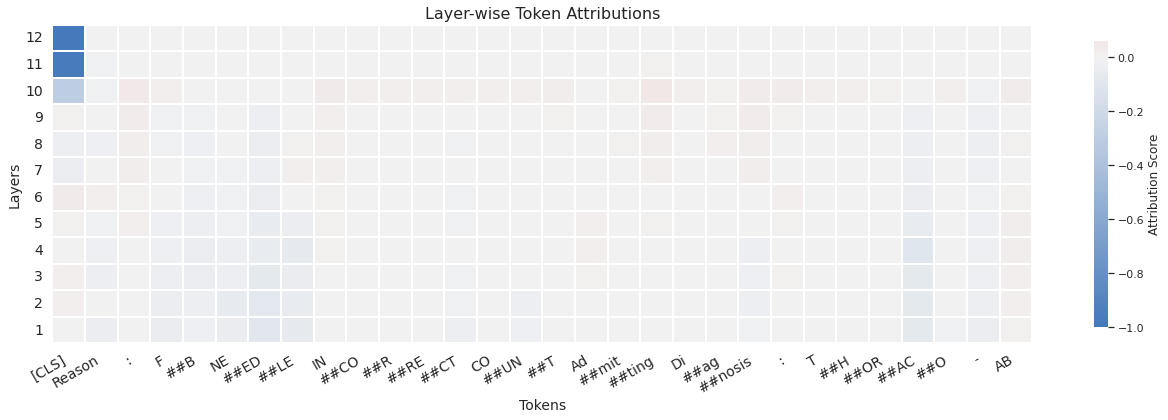

In [278]:
fig, ax = plt.subplots(figsize=(18,6))

xticklabels=truncated_tokens
yticklabels=list(reversed(range(1,13)))
cmap = sns.diverging_palette(250, 10, as_cmap=True)  

sns.heatmap(np.array(list(reversed(truncated_tokens_attributions))), 
            ax=ax, 
            cmap=cmap, 
            xticklabels=xticklabels, 
            yticklabels=yticklabels, 
            linewidth=0.2, 
            annot=False, 
            cbar_kws={'shrink': .9, 'label': 'Attribution Score'},  
            center=0)  

plt.xticks(rotation=30, ha='right', fontsize=14)  
plt.yticks(rotation=0, fontsize=14)  
plt.xlabel('Tokens', fontsize=14)  
plt.ylabel('Layers', fontsize=14) 
plt.title('Layer-wise Token Attributions', fontsize=16)  
plt.tight_layout()  
plt.show()

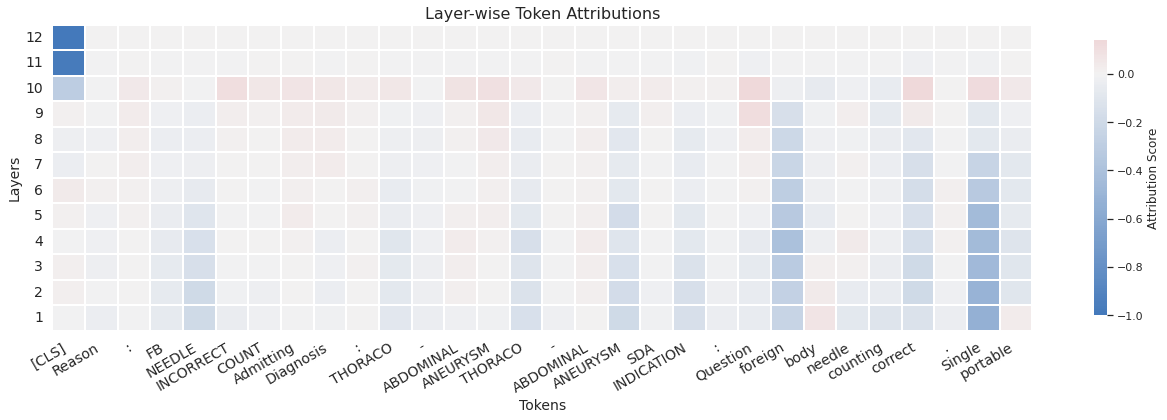

In [279]:
fig, ax = plt.subplots(figsize=(18,6))

xticklabels=truncated_words
yticklabels=list(reversed(range(1,13)))
cmap = sns.diverging_palette(250, 10, as_cmap=True)  

sns.heatmap(np.array(list(reversed(truncated_words_attributions))), 
            ax=ax, 
            cmap=cmap, 
            xticklabels=xticklabels, 
            yticklabels=yticklabels, 
            linewidth=0.2, 
            annot=False, 
            cbar_kws={'shrink': .9, 'label': 'Attribution Score'},  
            center=0)  

plt.xticks(rotation=30, ha='right', fontsize=14)  
plt.yticks(rotation=0, fontsize=14)  
plt.xlabel('Tokens', fontsize=14)  
plt.ylabel('Layers', fontsize=14) 
plt.title('Layer-wise Token Attributions', fontsize=16)  
plt.tight_layout()  
plt.show()

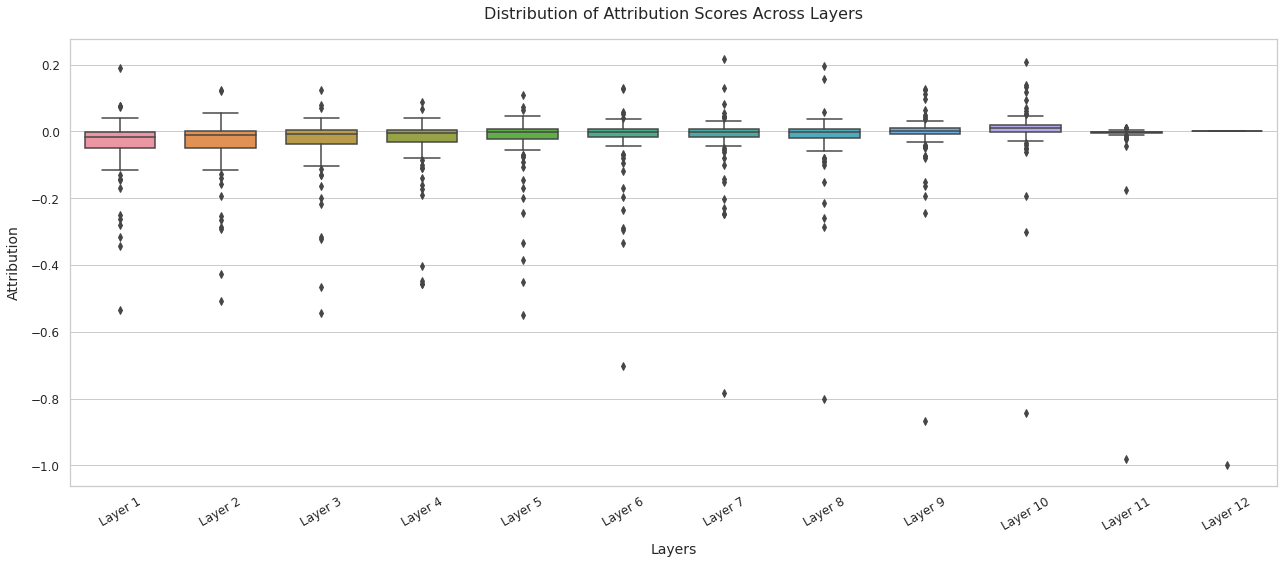

In [280]:
fig, ax = plt.subplots(figsize=(18, 8))

sns.boxplot(data=layer_attrs, width=0.7)  

ax.set_xlabel('Layers', fontsize=14, labelpad=10) 
ax.set_ylabel('Attribution', fontsize=14, labelpad=10)  
ax.set_title('Distribution of Attribution Scores Across Layers', fontsize=16, pad=20) 
ax.tick_params(axis='x', labelsize=12)  
ax.tick_params(axis='y', labelsize=12)  
ax.set_xticklabels(['Layer {}'.format(i+1) for i in range(len(layer_attrs))], rotation=30) 
plt.tight_layout()  
plt.show()  

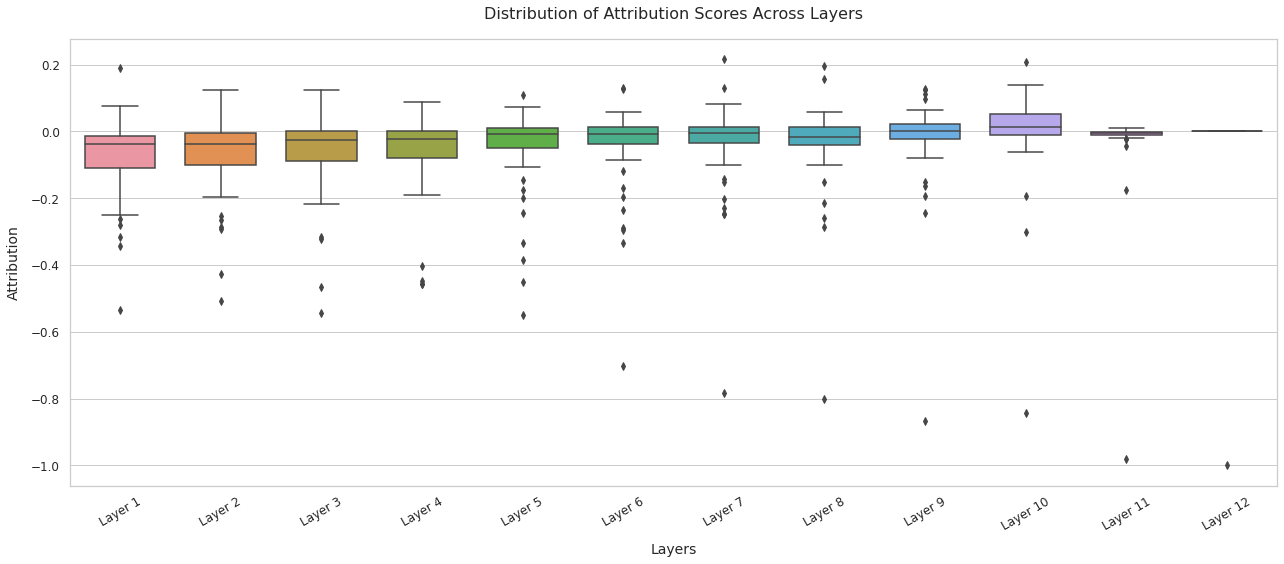

In [281]:
fig, ax = plt.subplots(figsize=(18, 8))

sns.boxplot(data=aggregated_layer_attrs, width=0.7)  

ax.set_xlabel('Layers', fontsize=14, labelpad=10) 
ax.set_ylabel('Attribution', fontsize=14, labelpad=10)  
ax.set_title('Distribution of Attribution Scores Across Layers', fontsize=16, pad=20) 
ax.tick_params(axis='x', labelsize=12)  
ax.tick_params(axis='y', labelsize=12)  
ax.set_xticklabels(['Layer {}'.format(i+1) for i in range(len(layer_attrs))], rotation=30) 
plt.tight_layout()  
plt.show()  

In [282]:
def pdf_attr(attrs, bins=20):
    return np.histogram(attrs, bins=bins, density=True)[0]

In [283]:
layer_attrs_end_pdf = map(lambda layer_attrs: pdf_attr(layer_attrs), layer_attrs)
layer_attrs_end_pdf = np.array(list(layer_attrs_end_pdf))

layer_attrs_end_pdf_norm = np.linalg.norm(layer_attrs_end_pdf, axis=-1, ord=1)
layer_attrs_end_pdf = np.transpose(layer_attrs_end_pdf)
layer_attrs_end_pdf = np.divide(layer_attrs_end_pdf, layer_attrs_end_pdf_norm, where=layer_attrs_end_pdf_norm!=0)

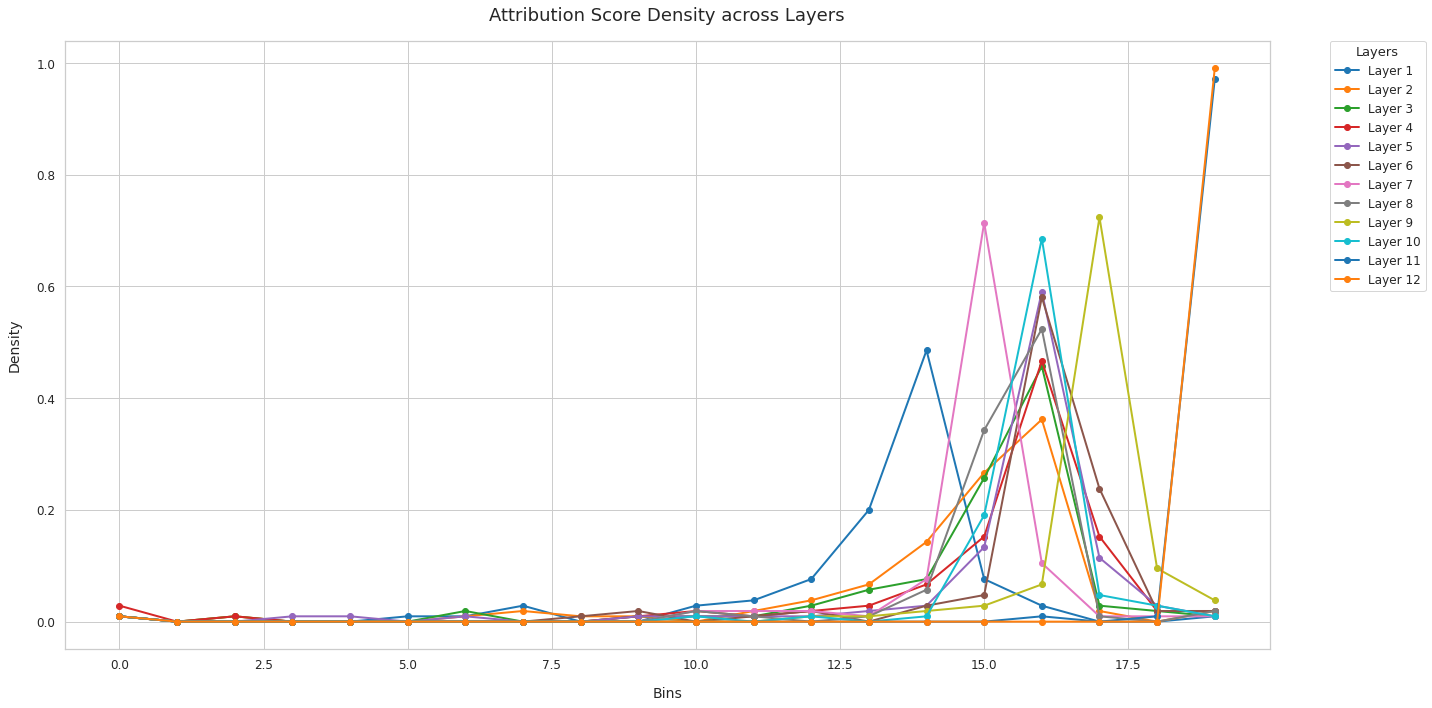

In [284]:
sns.set(style='whitegrid')

fig, ax = plt.subplots(figsize=(20, 10))

colors = sns.color_palette("tab10", n_colors=12) 
for i, layer_data in enumerate(layer_attrs_end_pdf.T):  
    ax.plot(layer_data, marker='o', linestyle='-', color=colors[i], markersize=6, linewidth=2, label=f'Layer {i+1}')

ax.set_xlabel('Bins', fontsize=14, labelpad=15)
ax.set_ylabel('Density', fontsize=14, labelpad=15)
ax.set_title('Attribution Score Density across Layers', fontsize=18, pad=20)

ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend(title='Layers', title_fontsize='13', fontsize='12', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

In [285]:
attr_sum = np.array(layer_attrs).sum(-1)

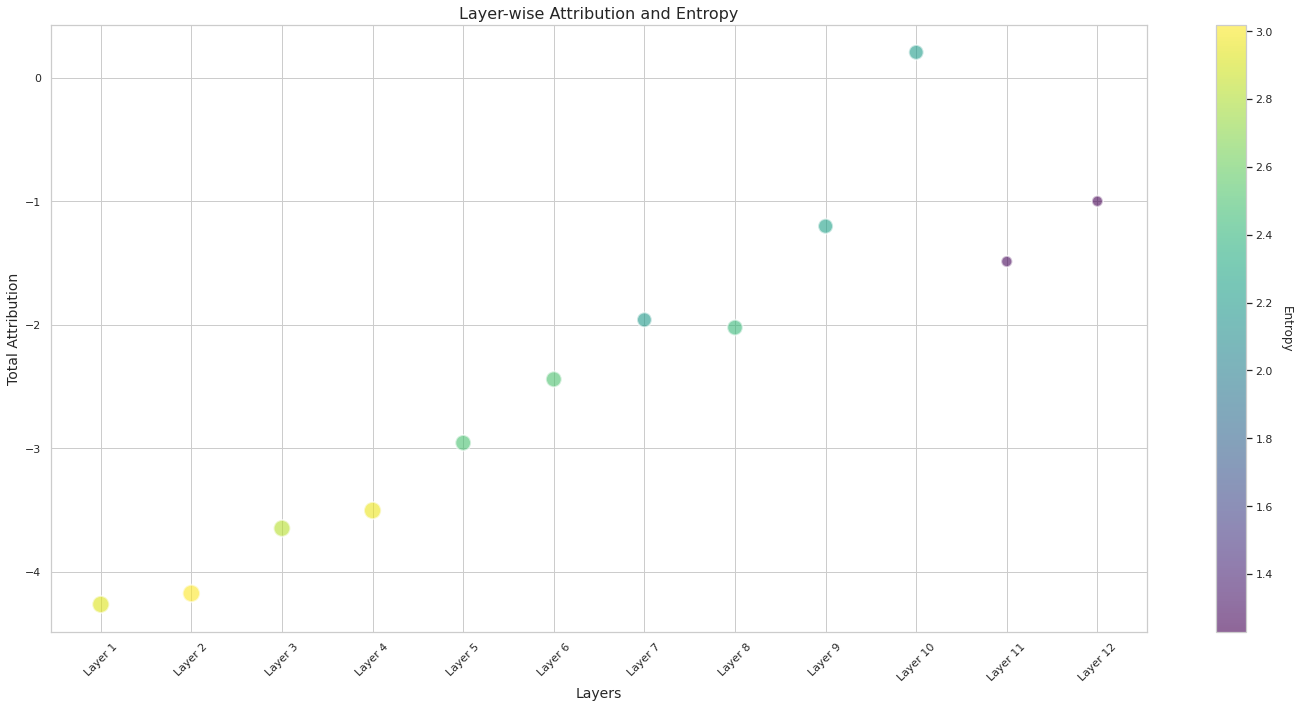

In [286]:
fig, ax = plt.subplots(figsize=(20, 10))

min_nonzero = np.min(layer_attrs_end_pdf[layer_attrs_end_pdf > 0])
layer_attrs_end_pdf[layer_attrs_end_pdf == 0] = min_nonzero

layer_attrs_end_pdf_log = np.log2(layer_attrs_end_pdf)

entropies = -(layer_attrs_end_pdf * layer_attrs_end_pdf_log).sum(0)

scaling_factor = 100
sizes = entropies * scaling_factor
layers = np.arange(1, 13)  

scatter = ax.scatter(layers, attr_sum, s=sizes, alpha=0.6, cmap='viridis', c=entropies, edgecolors='w', linewidths=2)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Entropy', rotation=270, labelpad=20)

ax.set_xlabel('Layers', fontsize=14)
ax.set_ylabel('Total Attribution', fontsize=14)
ax.set_title('Layer-wise Attribution and Entropy', fontsize=16)
ax.set_xticks(layers)
ax.set_xticklabels(['Layer {}'.format(i) for i in layers], rotation=45)

plt.tight_layout()
plt.show()

### Feature Ablation

In [210]:
device = 'cpu'
best_model.to(device)

best_model.eval()
best_model.zero_grad()

In [211]:
batch_size = 1

In [212]:
multi_test_loader  = DataLoader(multi_test_dataset,  batch_size=batch_size, shuffle=False, 
                                collate_fn=multimodal_collate_fn)
test_dataloader_iter = iter(multi_test_loader)

In [213]:
batch = next(test_dataloader_iter)

In [214]:
def ablate_and_predict(model, data, ablation_type='time_step', ablation_index=[]):
    
    model.eval()
    
    batch = {k: v.to(device) for k, v in data.items()}  

    with torch.no_grad():
        baseline_out, _, _ = model(input_ids= batch['input_ids'],
                                   attention_mask= batch['attention_mask'],
                                   token_type_ids= batch['token_type_ids'],
                                   ehr_data= batch['ehr_data'],
                                   seq_lengths= batch['ehr_length'])

        baseline_out = nn.Softmax(dim=1)(baseline_out)
        baseline_out = baseline_out.detach().cpu().numpy()
        baseline_out = baseline_out[:,1]

    ablation_results = {}
    
    for index in ablation_index:
        
        X_ablated = batch['ehr_data'].clone()
        
        if ablation_type == 'time_step':
            X_ablated[:, index, :] = 0  
        elif ablation_type == 'feature':
            X_ablated[:, :, index] = 0  
            
    batch['ehr_data'] = X_ablated
        
    with torch.no_grad():
        ablated_out, _, _ = model(input_ids= batch['input_ids'],
                                   attention_mask= batch['attention_mask'],
                                   token_type_ids= batch['token_type_ids'],
                                   ehr_data= batch['ehr_data'],
                                   seq_lengths= batch['ehr_length'])

        ablated_out = nn.Softmax(dim=1)(ablated_out)
        ablated_out = ablated_out.detach().cpu().numpy()
        ablated_out = ablated_out[:,1]

    ablation_results = abs(baseline_out - ablated_out)[0]  
        
    return ablation_results

In [215]:
def ablate_all_time_steps(model, data):

    num_time_steps = data['ehr_data'].shape[1]  
    
    ablation_results = {}
    
    for time_step in range(num_time_steps):
        
        ablation_difference = ablate_and_predict(model, data, ablation_type='time_step', ablation_index=[time_step])
        ablation_results['Hour ' + str(time_step + 1)] = np.round(ablation_difference, 4)
    
    return ablation_results

In [216]:
def ablate_features(model, data, feature_names):
    
    feature_groups = {}
    for feature in feature_names:
        if '_ind' in feature:
            base_feature = feature.replace('_ind', '')
            if base_feature in feature_groups:
                feature_groups[base_feature].append(feature)
            else:
                feature_groups[base_feature] = [feature]
        else:
            feature_groups[feature] = [feature]
    
    feature_indices = {name: [feature_names.index(f) for f in group] for name, group in feature_groups.items()}
    
    ablation_results = {}
    
    for feature, indices in feature_indices.items():
        ablation_difference = ablate_and_predict(model, data, ablation_type='feature', ablation_index=indices)
        ablation_results[feature] = np.round(ablation_difference, 4)
        
    sorted_ablation_results = {k: v for k, v in sorted(ablation_results.items(), key=lambda item: item[1], reverse=True)}

    
    return sorted_ablation_results

In [217]:
def plot_feature_importance(results):
    
    time_steps = list(results.keys())
    importance_values = [results[time_step] for time_step in time_steps]
    
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))
    
    sns.barplot(x=time_steps, y=importance_values, palette='viridis')
    
    plt.title('Feature Importance Over Time Steps', fontsize=16)
    plt.xlabel('Time Step',  fontsize=14)
    plt.ylabel('Importance', fontsize=14)
    plt.xticks(rotation=35)
    plt.tight_layout()
    plt.show()

In [218]:
def plot_feature_attributions(data, feature_names):
    
    plt.figure(figsize=(18, 12))

    bars = plt.bar(range(len(data)), data, color='skyblue', edgecolor='blue')

    for bar in bars:
        yval = bar.get_height()
        if yval >= 0: 
            plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005*yval, round(yval, 4), 
                     ha='center', va='bottom', fontsize=10)
        else:
            plt.text(bar.get_x() + bar.get_width()/2, yval - 0.005*yval, round(yval, 4), 
                     ha='center', va='bottom', fontsize=10)

    plt.xticks(range(len(data)), feature_names, rotation=45, ha="right", fontsize=12)
    
    plt.ylabel('Attribution', fontsize=14)
    plt.xlabel('Features', fontsize=14)
    plt.title('Feature Attributions', fontsize=16)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [219]:
time_importance = ablate_all_time_steps(best_model, batch)

In [220]:
feature_importance = ablate_features(best_model, batch, columns)

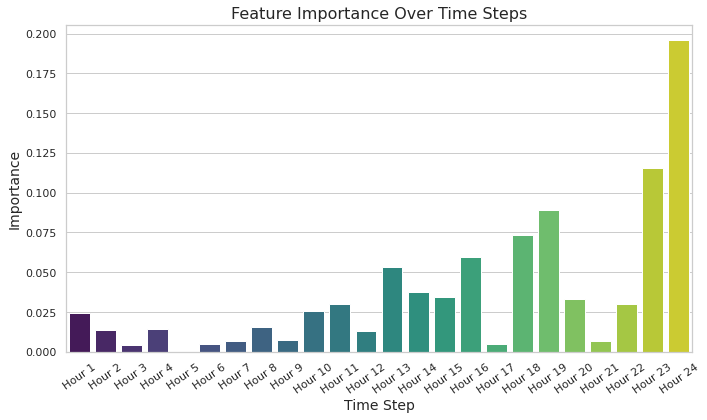

In [221]:
plot_feature_importance(time_importance)

In [222]:
number_top_features = 30

top_importance = list(feature_importance.values())[:30]
top_features = list(feature_importance.keys())[:30]

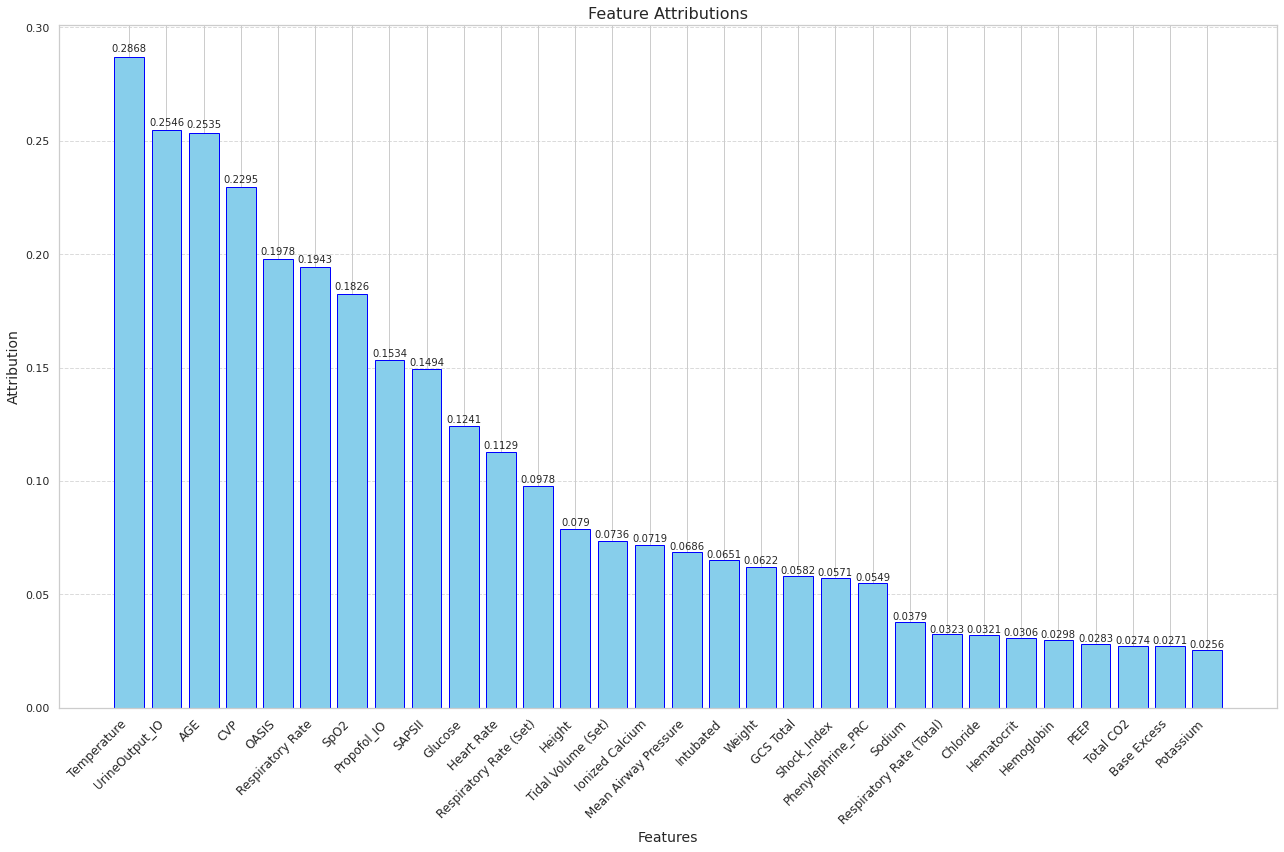

In [223]:
plot_feature_attributions(top_importance, top_features)